In [ ]:
#import the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

%matplotlib inline

In [ ]:
df_adult = pd.read_csv("https://ourworldindata.org/grapher/literacy-rate-adults.csv?v=1&csvType=full&useColumnShortNames=true",storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})

df_adult.head()

,entity,code,year,adult_literacy_rate__population_15plus_years__both_sexes__pct__lr_ag15t99
0,Afghanistan,AFG,1979,18.00000
1,Afghanistan,AFG,2011,31.00000
2,Afghanistan,AFG,2015,33.75384
3,Afghanistan,AFG,2021,37.00000
4,Albania,ALB,2001,99.00000


In [ ]:
len(df_adult)

1725

In [ ]:
df_adult.duplicated().sum()

np.int64(0)

In [ ]:
df_adult = df_adult.rename(columns={'entity': 'Country'})
df_adult = df_adult.rename(columns={'adult_literacy_rate__population_15plus_years__both_sexes__pct__lr_ag15t99': 'adult_literacy_rate'})

In [ ]:
df_adult = df_adult.loc[(df_adult['year'] >= 1990) & (df_adult['year'] <= 2023)]
df_adult = df_adult.drop(columns=['code'])
df_adult.head()

,Country,year,adult_literacy_rate
1,Afghanistan,2011,31.00000
2,Afghanistan,2015,33.75384
3,Afghanistan,2021,37.00000
4,Albania,2001,99.00000
5,Albania,2008,96.00000


In [ ]:
df_adult.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1420 entries, 1 to 1724
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Country              1420 non-null   object 
 1   year                 1420 non-null   int64  
 2   adult_literacy_rate  1420 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 44.4+ KB


In [ ]:
df_adult.isnull().sum()

,0
Country,0
year,0
adult_literacy_rate,0


In [ ]:
df_adult.describe()

,year,adult_literacy_rate
count,1420.000000,1420.000000
mean,2008.541549,79.993777
std,9.102910,18.140324
min,1990.000000,11.000000
25%,2001.000000,67.247242
50%,2010.000000,86.699685
75%,2016.000000,94.723720
max,2023.000000,100.000000


In [ ]:
numeric_features = [feature for feature in df_adult.columns if df_adult[feature].dtype != 'O']
categorical_features = [feature for feature in df_adult.columns if df_adult[feature].dtype == 'O']

In [ ]:
# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 2 numerical features : ['year', 'adult_literacy_rate']

We have 1 categorical features : ['Country']


In [ ]:
from os import remove
import pandas as pd
df_young = pd.read_csv("https://ourworldindata.org/grapher/literacy-rate-of-young-men-and-women.csv?v=1&csvType=full&useColumnShortNames=true",storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})
df_young.head()

df_young = df_young.loc[(df_young['year'] >= 1990) & (df_young['year'] <= 2023)]
df_young
df_young = df_young.rename(columns={'entity': 'Country'})
df_young = df_young.rename(columns={'youth_literacy_rate__population_15_24_years__male__pct__lr_ag15t24_m': 'Youth_literacy_rate_male'})
df_young = df_young.rename(columns={'youth_literacy_rate__population_15_24_years__female__pct__lr_ag15t24_f': 'Youth_literacy_rate_female'})
df_young = df_young.drop(columns=['code'])

In [ ]:
len(df_young)

1697

In [ ]:
df_young.head()

,Country,year,Youth_literacy_rate_male,Youth_literacy_rate_female,owid_region
1,Afghanistan,2011,62.00000,32.00000,Asia
2,Afghanistan,2015,57.73505,25.48416,Asia
3,Afghanistan,2021,71.00000,42.00000,Asia
4,Afghanistan,2022,83.40000,44.17171,Asia
5,Albania,2001,99.00000,99.00000,Europe


In [ ]:
df_young.isnull().sum()

,0
Country,0
year,0
Youth_literacy_rate_male,77
Youth_literacy_rate_female,0
owid_region,598


In [ ]:
# Fill literacy rate
df_young['Youth_literacy_rate_male'].fillna(df_young['Youth_literacy_rate_male'].mean(), inplace = True)
df_young['owid_region'].fillna('Unknown', inplace = True)

In [ ]:
df_young.isnull().sum()

,0
Country,0
year,0
Youth_literacy_rate_male,0
Youth_literacy_rate_female,0
owid_region,0


In [ ]:
df_literacy  = pd.merge(df_adult, df_young, on=['Country', 'year'], how='inner')
df_literacy.head()

,Country,year,adult_literacy_rate,Youth_literacy_rate_male,Youth_literacy_rate_female,owid_region
0,Afghanistan,2011,31.00000,62.00000,32.00000,Asia
1,Afghanistan,2015,33.75384,57.73505,25.48416,Asia
2,Afghanistan,2021,37.00000,71.00000,42.00000,Asia
3,Albania,2001,99.00000,99.00000,99.00000,Europe
4,Albania,2008,96.00000,99.00000,99.00000,Europe


In [ ]:
df_literacy['literacy_gender_gap'] = (df_literacy['Youth_literacy_rate_male'] - df_literacy['Youth_literacy_rate_female'])

In [ ]:
df_literacy['Youth_Literacy_Average'] = (df_literacy['Youth_literacy_rate_male'] + df_literacy['Youth_literacy_rate_female']) / 2

In [ ]:
df_literacy.head()

,Country,year,adult_literacy_rate,Youth_literacy_rate_male,Youth_literacy_rate_female,owid_region,literacy_gender_gap,Youth_Literacy_Average
0,Afghanistan,2011,31.00000,62.00000,32.00000,Asia,30.00000,47.000000
1,Afghanistan,2015,33.75384,57.73505,25.48416,Asia,32.25089,41.609605
2,Afghanistan,2021,37.00000,71.00000,42.00000,Asia,29.00000,56.500000
3,Albania,2001,99.00000,99.00000,99.00000,Europe,0.00000,99.000000
4,Albania,2008,96.00000,99.00000,99.00000,Europe,0.00000,99.000000


In [ ]:
df_literacy.duplicated().sum()

np.int64(0)

In [ ]:
df_literacy.isnull().sum()

,0
Country,0
year,0
adult_literacy_rate,0
Youth_literacy_rate_male,0
Youth_literacy_rate_female,0
owid_region,0
literacy_gender_gap,0
Youth_Literacy_Average,0


In [ ]:
df_literacy.describe()

,year,adult_literacy_rate,Youth_literacy_rate_male,Youth_literacy_rate_female,literacy_gender_gap,Youth_Literacy_Average
count,1405.000000,1405.000000,1405.000000,1405.000000,1405.000000,1405.000000
mean,2008.554448,80.042404,90.387280,86.272507,4.114773,88.329894
std,9.109381,18.086364,11.916495,17.411604,6.801157,14.526509
min,1990.000000,11.000000,25.000000,9.000000,-19.000000,17.500000
25%,2001.000000,67.267330,86.000000,76.613550,0.000000,81.000000
50%,2010.000000,86.747480,96.000000,95.528910,0.424560,95.442225
75%,2016.000000,94.771680,98.783860,99.000000,7.778180,98.870335
max,2023.000000,100.000000,100.000000,100.000000,48.000000,100.000000


In [ ]:
#Univariate Analysis: Explore each variable individually (e.g., histograms, box plots, bar charts for literacy rates, GDP, etc.).

In [ ]:
numeric_features = [feature for feature in df_literacy.columns if df_literacy[feature].dtype != 'O']
categorical_features = [feature for feature in df_literacy.columns if df_literacy[feature].dtype == 'O']

In [ ]:
# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 6 numerical features : ['year', 'adult_literacy_rate', 'Youth_literacy_rate_male', 'Youth_literacy_rate_female', 'literacy_gender_gap', 'Youth_Literacy_Average']

We have 2 categorical features : ['Country', 'owid_region']


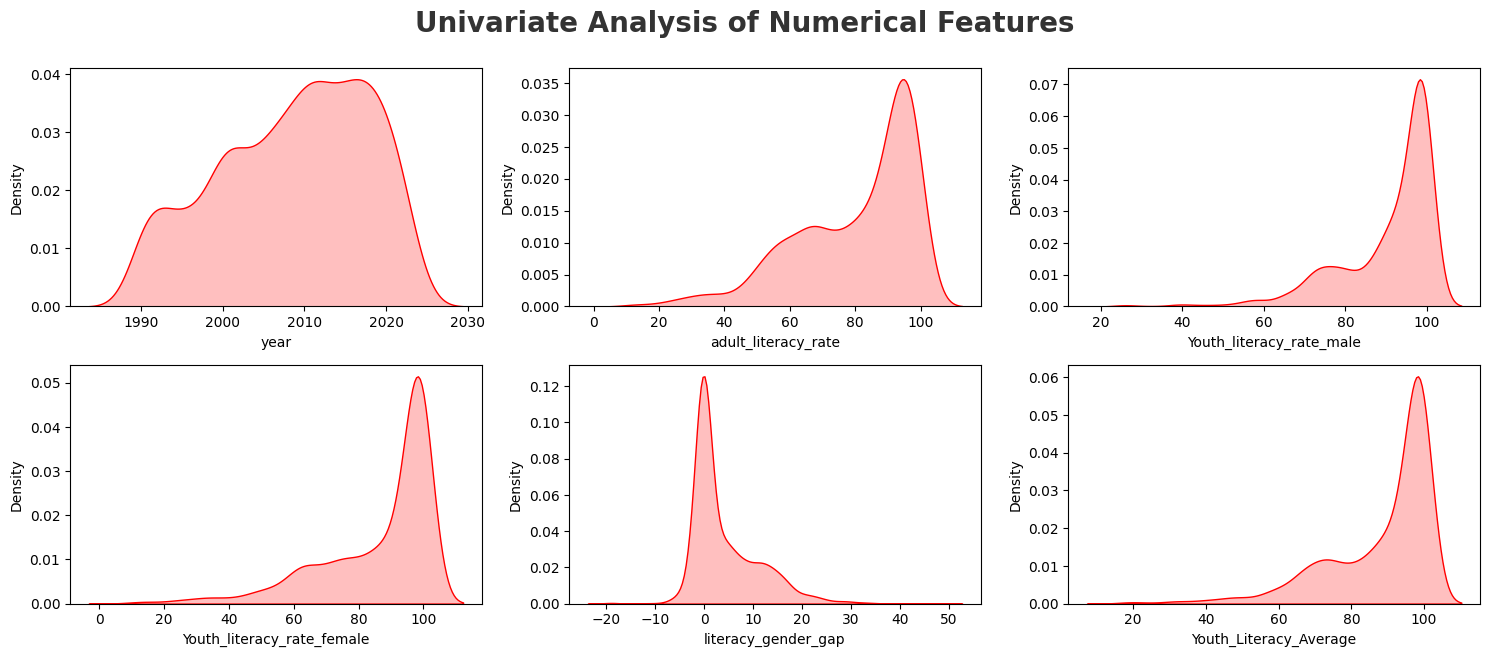

In [ ]:
# Proportion of count data on numerical columns

plt.figure(figsize=(15, 15))
plt.suptitle('Univariate Analysis of Numerical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(0, len(numeric_features)):
    plt.subplot(5, 3, i+1)
    sns.kdeplot(x=df_literacy[numeric_features[i]], shade=True, color='r')
    plt.xlabel(numeric_features[i])
    plt.tight_layout()

Year Distribution

The data is skewed toward recent years (2000–2020).
Very few records exist before 1980, indicating limited historical data.
Peak density appears around 2010–2020, meaning most analysis is based on modern data.

Adult Literacy Rate Distribution

The distribution is left-skewed (negatively skewed).
Most countries have high literacy rates (70%–100%).
Peak concentration is around 85%–95%, showing that globally literacy is relatively high.
Few countries fall below 50%, indicating low literacy is less common but still present.


1. year
Data spans roughly late 1980s to 2020+
Distribution is slightly skewed toward recent years
Indicates more data availability in modern years (2000–2020)
 2. adult_literacy_rate
Most values are concentrated between 70% and 100%
Peak around 90–100%
Slight left skew → fewer countries with low literacy
Suggests global improvement in adult literacy
 3. Youth_literacy_rate_male
Highly concentrated near 95–100%
Very narrow distribution
Indicates male youth literacy is very high globally
Minimal variation → most countries perform well
4. Youth_literacy_rate_female
Also peaks around 95–100%
Slightly wider spread than males
Some countries still have lower female literacy
Shows progress but small inequality remains
5. literacy_gender_gap
Centered around 0
Range from negative to positive values
Negative → female literacy higher
Positive → male literacy higher
Most values close to zero → gender gap is reducing globally

A few outliers → still inequality in some regions
📈 6. Youth_Literacy_Average
Strong peak near 95–100%
Very tight distribution
Confirms youth literacy is consistently high worldwide
Less variation compared to adults
🔥 Overall Key Insights
🌍 Youth literacy > Adult literacy (global trend)
👨‍👩‍👧 Gender gap is shrinking, but not fully closed
📉 Few countries still lag behind (seen in long tails)
📈 Strong improvement in literacy over time



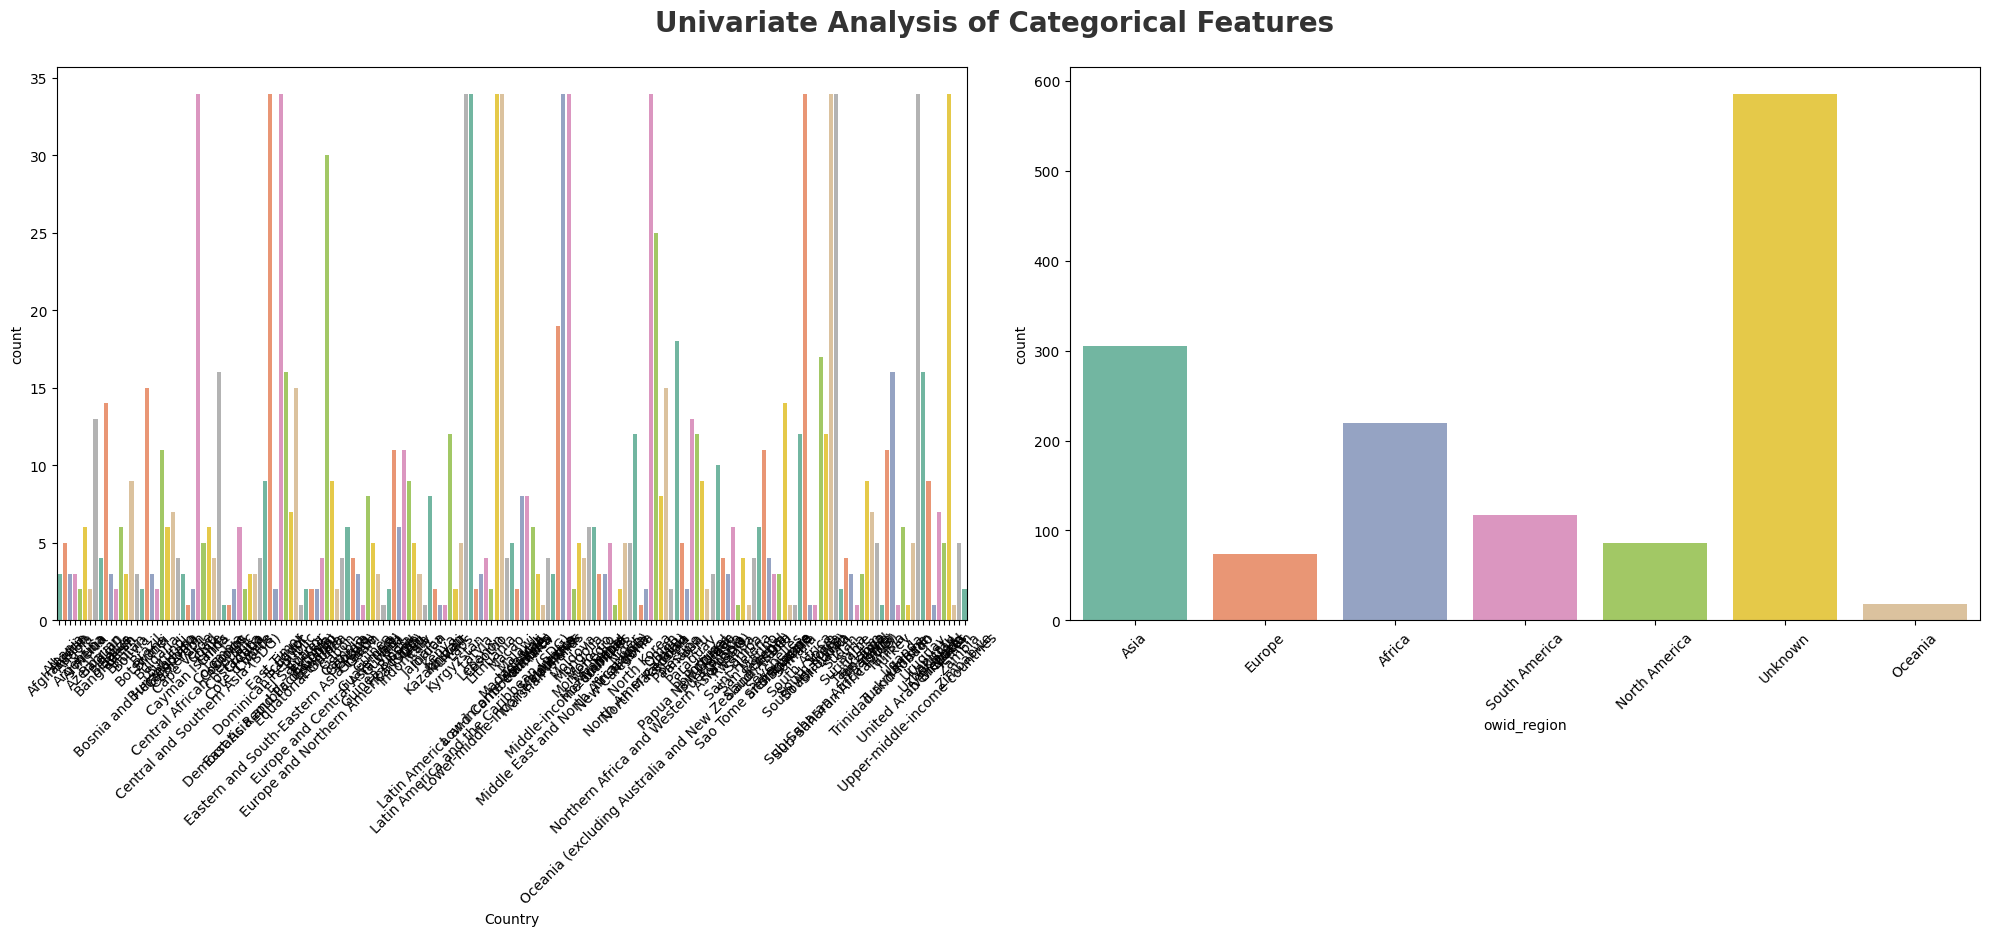

In [ ]:
# categorical columns
plt.figure(figsize=(20, 15))
plt.suptitle('Univariate Analysis of Categorical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)
category = ['Country', 'owid_region']
for i in range(0, len(category)):
    plt.subplot(2, 2, i+1)
    sns.countplot(x=df_literacy[category[i]],palette="Set2")
    plt.xlabel(category[i])
    plt.xticks(rotation=45)
    plt.tight_layout()

Region Distribution (Right Chart)
🔹 Key Observations:
Unknown region has the highest count
Indicates missing or undefined region data
Data cleaning may be required
Asia has the highest valid region count
Suggests more countries/data points from Asia
Africa is second highest
Good representation of developing regions
Europe, South America, North America
Moderate number of records
Oceania has the lowest count


In [ ]:
cols = ['adult_literacy_rate', 'Youth_literacy_rate_male', 'Youth_literacy_rate_female', 'literacy_gender_gap', 'Youth_Literacy_Average']

#['year', 'adult_literacy_rate', 'Youth_literacy_rate_male', 'Youth_literacy_rate_female', 'literacy_gender_gap', 'Youth_Literacy_Average']
#categorical features : ['Country', 'owid_region']

for col in cols:
    Q1 = df_literacy[col].quantile(0.25)
    Q3 = df_literacy[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df_literacy[(df_literacy[col] < lower) |
                             (df_literacy[col] > upper)]

    print(f"\n🔎 Outliers in {col}: {len(outliers)}")


🔎 Outliers in adult_literacy_rate: 13

🔎 Outliers in Youth_literacy_rate_male: 67

🔎 Outliers in Youth_literacy_rate_female: 44

🔎 Outliers in literacy_gender_gap: 51

🔎 Outliers in Youth_Literacy_Average: 45


In [ ]:
import numpy as np

Q1 = df_literacy[cols].quantile(0.25)
Q3 = df_literacy[cols].quantile(0.75)
IQR = Q3 - Q1

outliers_all = df_literacy[
    ((df_literacy[cols] < (Q1 - 1.5 * IQR)) |
     (df_literacy[cols] > (Q3 + 1.5 * IQR))).any(axis=1)
]

#print(outliers_all)

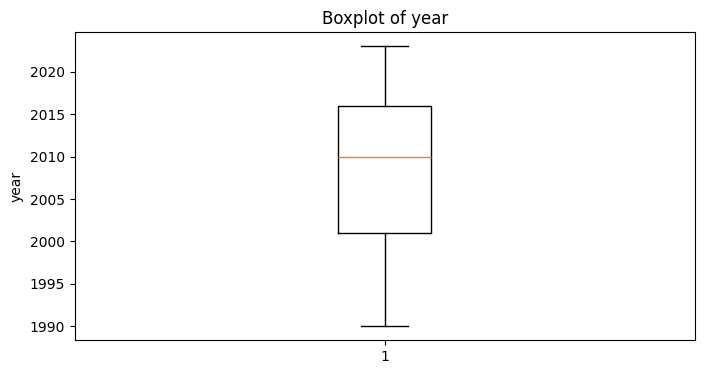

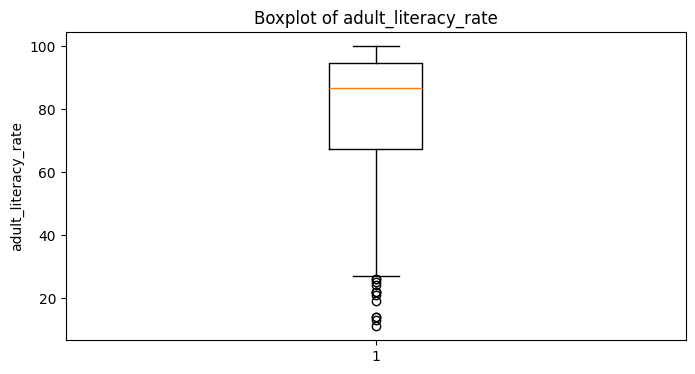

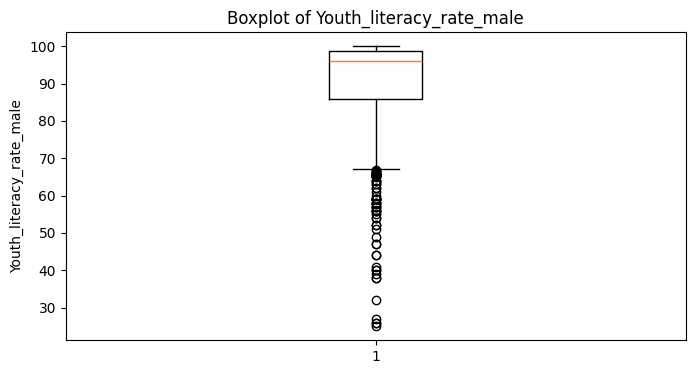

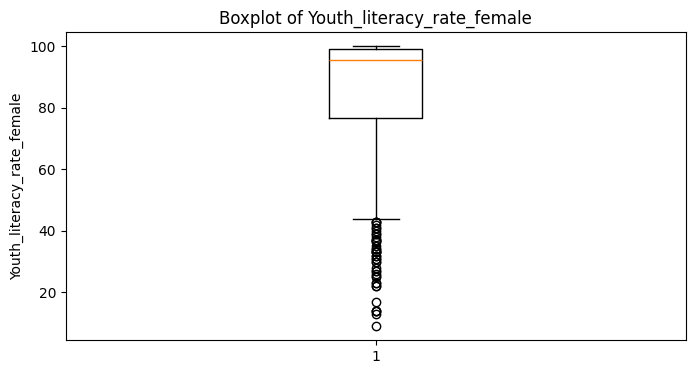

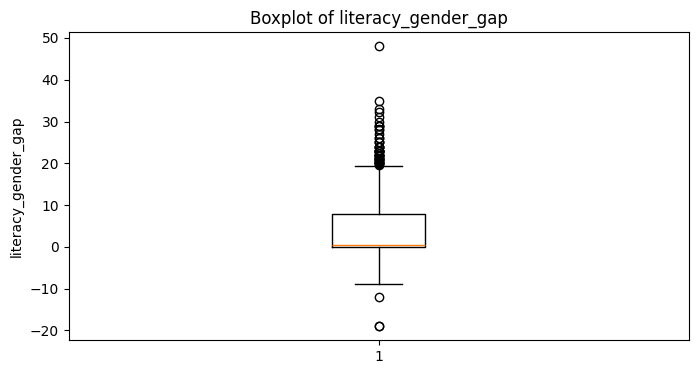

In [ ]:
import matplotlib.pyplot as plt
cols = ['year','adult_literacy_rate', 'Youth_literacy_rate_male', 'Youth_literacy_rate_female', 'literacy_gender_gap', 'Youth_Literacy_Average']

for i in range(0, 5):
    plt.figure(figsize=(8, 4))
    plt.boxplot(df_literacy[cols[i]])
    plt.title(f"Boxplot of {cols[i]}")
    plt.ylabel(cols[i])
    plt.show()



In [ ]:
cols = ['adult_literacy_rate', 'Youth_literacy_rate_male', 'Youth_literacy_rate_female', 'literacy_gender_gap', 'Youth_Literacy_Average']
numeric_features = [feature for feature in df_literacy.columns if df_literacy[feature].dtype != 'O']
categorical_features = [feature for feature in df_literacy.columns if df_literacy[feature].dtype == 'O']

In [ ]:
'''import seaborn as sns
sns.set(rc={'figure.figsize':(11.7,8.27)})

# Plot
for i in range(0, len(numeric_features)):
  sns.pairplot(df_literacy)

# Show|
plt.show()'''



"import seaborn as sns\nsns.set(rc={'figure.figsize':(11.7,8.27)})\n\n# Plot\nfor i in range(0, len(numeric_features)):\n  sns.pairplot(df_literacy)\n\n# Show|\nplt.show()"

In [ ]:
cols = ['Country','year','adult_literacy_rate', 'Youth_literacy_rate_male', 'Youth_literacy_rate_female']

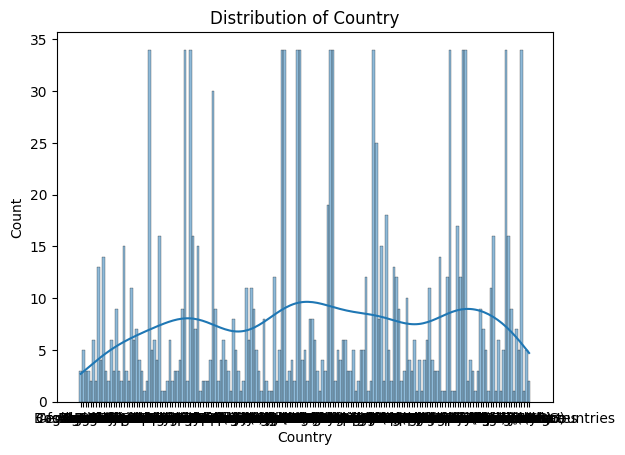

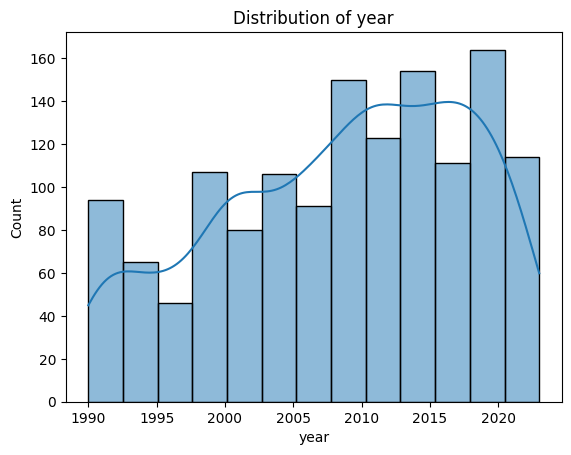

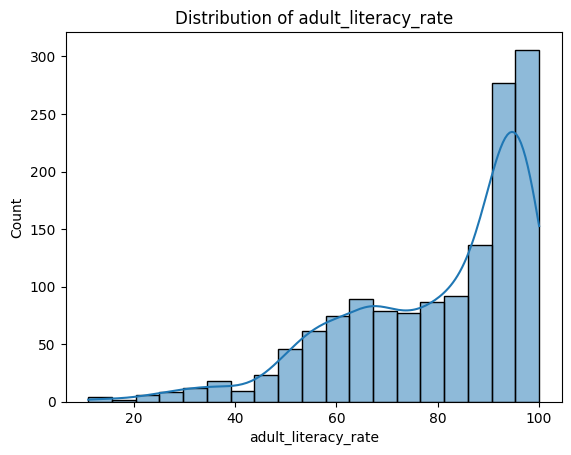

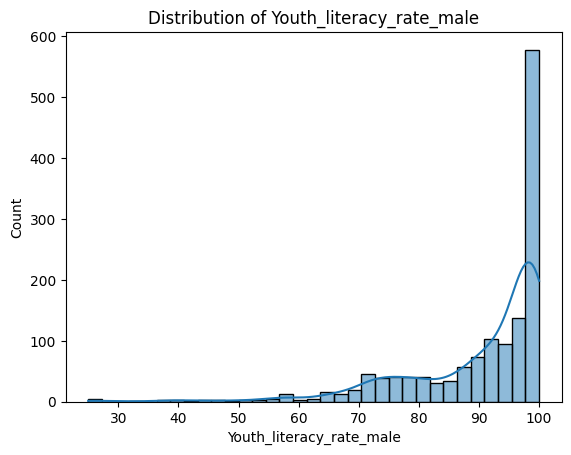

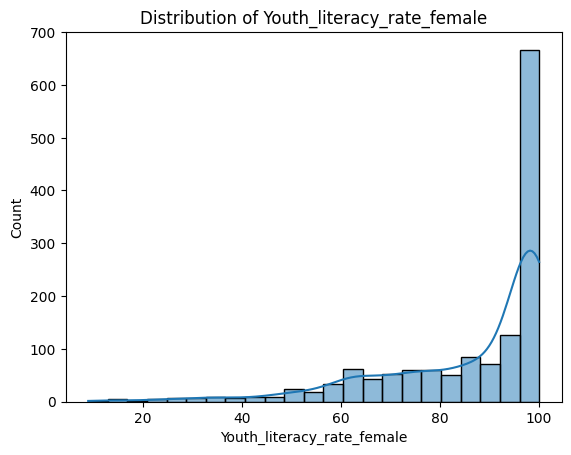

In [ ]:
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
for col in cols:
    plt.figure()
    sns.histplot(df_literacy[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

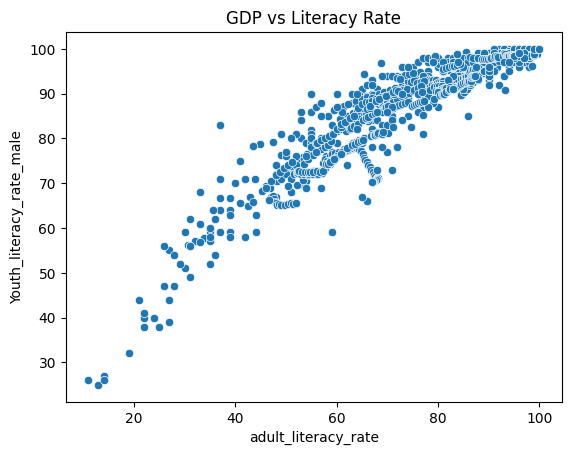

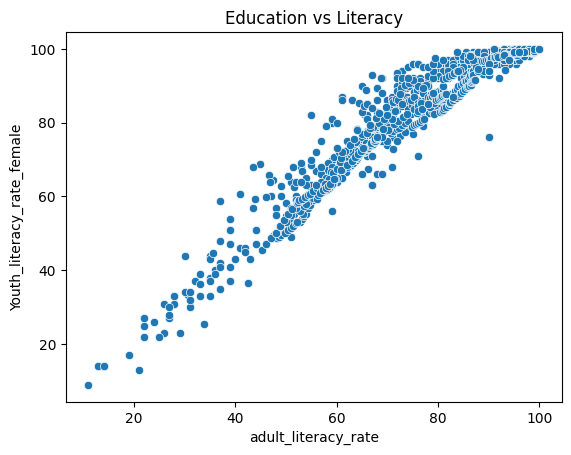

In [ ]:
# GDP vs Literacy
plt.figure()
sns.scatterplot(x='adult_literacy_rate', y='Youth_literacy_rate_male', data=df_literacy)
plt.title("GDP vs Literacy Rate")
plt.show()

# Education vs Literacy
plt.figure()
sns.scatterplot(x='adult_literacy_rate', y='Youth_literacy_rate_female', data=df_literacy)
plt.title("Education vs Literacy")
plt.show()

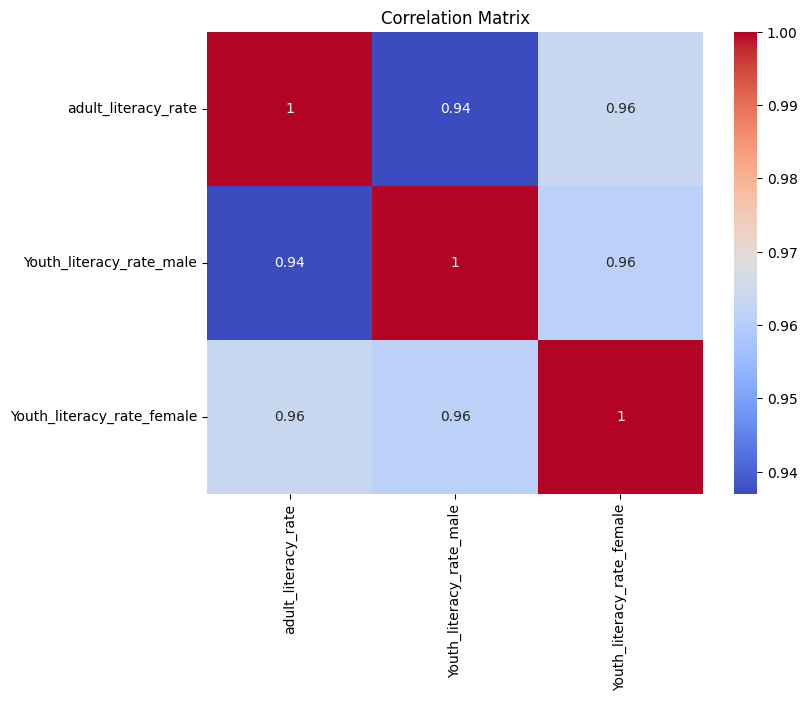

In [ ]:
cols = ['adult_literacy_rate', 'Youth_literacy_rate_male', 'Youth_literacy_rate_female']
corr = df_literacy[cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

1. Strong Positive Correlation Between Literacy Variables
  Adult vs Male Youth Literacy → 0.94
  Adult vs Female Youth Literacy → 0.96
  Male vs Female Youth Literacy → 0.96

  All literacy indicators are very strongly related
  If one increases, others also increase
  Countries with high adult literacy also have high youth literacy

2. Male & Female Youth Literacy Are Almost Identical
Correlation = 0.96 (very high)

  Gender gap is very small globally
  Improvements in education are affecting both genders equally

In [ ]:
df_literacy.to_csv("df_literacy.csv")

In [ ]:
df_illiterate_world_population = pd.read_csv("https://ourworldindata.org/grapher/literate-and-illiterate-world-population.csv?v=1&csvType=full&useColumnShortNames=true",storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})
df_illiterate_world_population.head()

,entity,code,year,illiteracy_rate,literacy_rate
0,Afghanistan,AFG,1950,97.000000,3.00000
1,Afghanistan,AFG,1979,82.000000,18.00000
2,Afghanistan,AFG,2011,69.000000,31.00000
3,Afghanistan,AFG,2015,66.246155,33.75384
4,Afghanistan,AFG,2021,63.000000,37.00000


In [ ]:
df_illiterate_world_population = df_illiterate_world_population.loc[(df_illiterate_world_population['year'] >= 1990) & (df_illiterate_world_population['year'] <= 2023)]
df_illiterate_world_population = df_illiterate_world_population.rename(columns={'entity': 'Country'})
df_illiterate_world_population = df_illiterate_world_population.drop(columns=['code'])

df_illiterate_world_population = df_illiterate_world_population.sort_values(by=['Country', 'year'])
df_illiterate_world_population['Literacy_Growth_Rate'] = (df_illiterate_world_population.groupby('Country')['literacy_rate'].pct_change() * 100)
df_illiterate_world_population['Literacy_Growth_Rate'] = df_illiterate_world_population['Literacy_Growth_Rate'].fillna(0)

In [ ]:
df_illiterate_world_population.head()

,Country,year,illiteracy_rate,literacy_rate,Literacy_Growth_Rate
2,Afghanistan,2011,69.000000,31.00000,0.000000
3,Afghanistan,2015,66.246155,33.75384,8.883355
4,Afghanistan,2021,63.000000,37.00000,9.617158
6,Albania,2001,1.000000,99.00000,0.000000
7,Albania,2008,4.000000,96.00000,-3.030303


In [ ]:
df_illiterate_world_population['Illiteracy_Percentage'] = (100 - df_illiterate_world_population['literacy_rate'])
#df_illiterate_world_population['Illiteracy_%'] = (100 - df_illiterate_world_population['literacy_rate'])

# Ensure values stay between 0–100
df_illiterate_world_population['Illiteracy_Percentage'] = (
    df_illiterate_world_population['Illiteracy_Percentage'].clip(0, 100)
)

In [ ]:
df_illiterate_world_population.head()

,Country,year,illiteracy_rate,literacy_rate,Literacy_Growth_Rate,Illiteracy_Percentage
2,Afghanistan,2011,69.000000,31.00000,0.000000,69.00000
3,Afghanistan,2015,66.246155,33.75384,8.883355,66.24616
4,Afghanistan,2021,63.000000,37.00000,9.617158,63.00000
6,Albania,2001,1.000000,99.00000,0.000000,1.00000
7,Albania,2008,4.000000,96.00000,-3.030303,4.00000


In [ ]:
df_illiterate_world_population.isnull().sum()

,0
Country,0
year,0
illiteracy_rate,0
literacy_rate,0
Literacy_Growth_Rate,0
Illiteracy_Percentage,0


In [ ]:
cols = ['illiteracy_rate', 'literacy_rate']

for col in cols:
    Q1 = df_illiterate_world_population[col].quantile(0.25)
    Q3 = df_illiterate_world_population[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df_illiterate_world_population[(df_illiterate_world_population[col] < lower) |
                             (df_illiterate_world_population[col] > upper)]

    print(f"\n🔎 Outliers in {col}: {len(outliers)}")


🔎 Outliers in illiteracy_rate: 12

🔎 Outliers in literacy_rate: 12


In [ ]:
df_illiterate_world_population['illiteracy_rate'] = df_illiterate_world_population['illiteracy_rate'].clip(upper=73)

In [ ]:
df_illiterate_world_population['literacy_rate'] = df_illiterate_world_population['literacy_rate'].clip(lower=50)

In [ ]:
# Example
df_illiterate_world_population.to_csv("illiterate_world_population.csv")

In [ ]:
numeric_features = [feature for feature in df_illiterate_world_population.columns if df_illiterate_world_population[feature].dtype != 'O']
categorical_features = [feature for feature in df_illiterate_world_population.columns if df_illiterate_world_population[feature].dtype == 'O']

In [ ]:
# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 5 numerical features : ['year', 'illiteracy_rate', 'literacy_rate', 'Literacy_Growth_Rate', 'Illiteracy_Percentage']

We have 1 categorical features : ['Country']


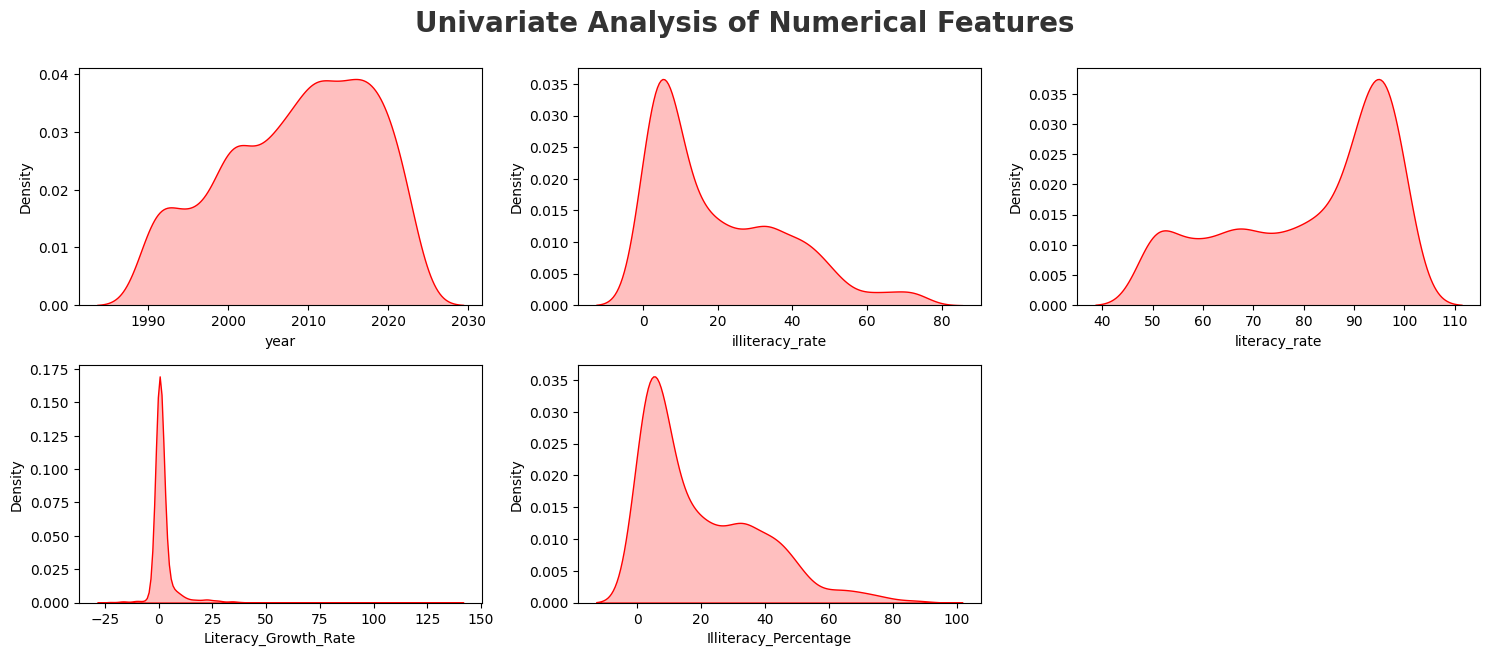

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 15))
plt.suptitle('Univariate Analysis of Numerical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(0, len(numeric_features)):
    plt.subplot(5, 3, i+1)
    sns.kdeplot(x=df_illiterate_world_population[numeric_features[i]], shade=True, color='r')
    plt.xlabel(numeric_features[i])
    plt.tight_layout()


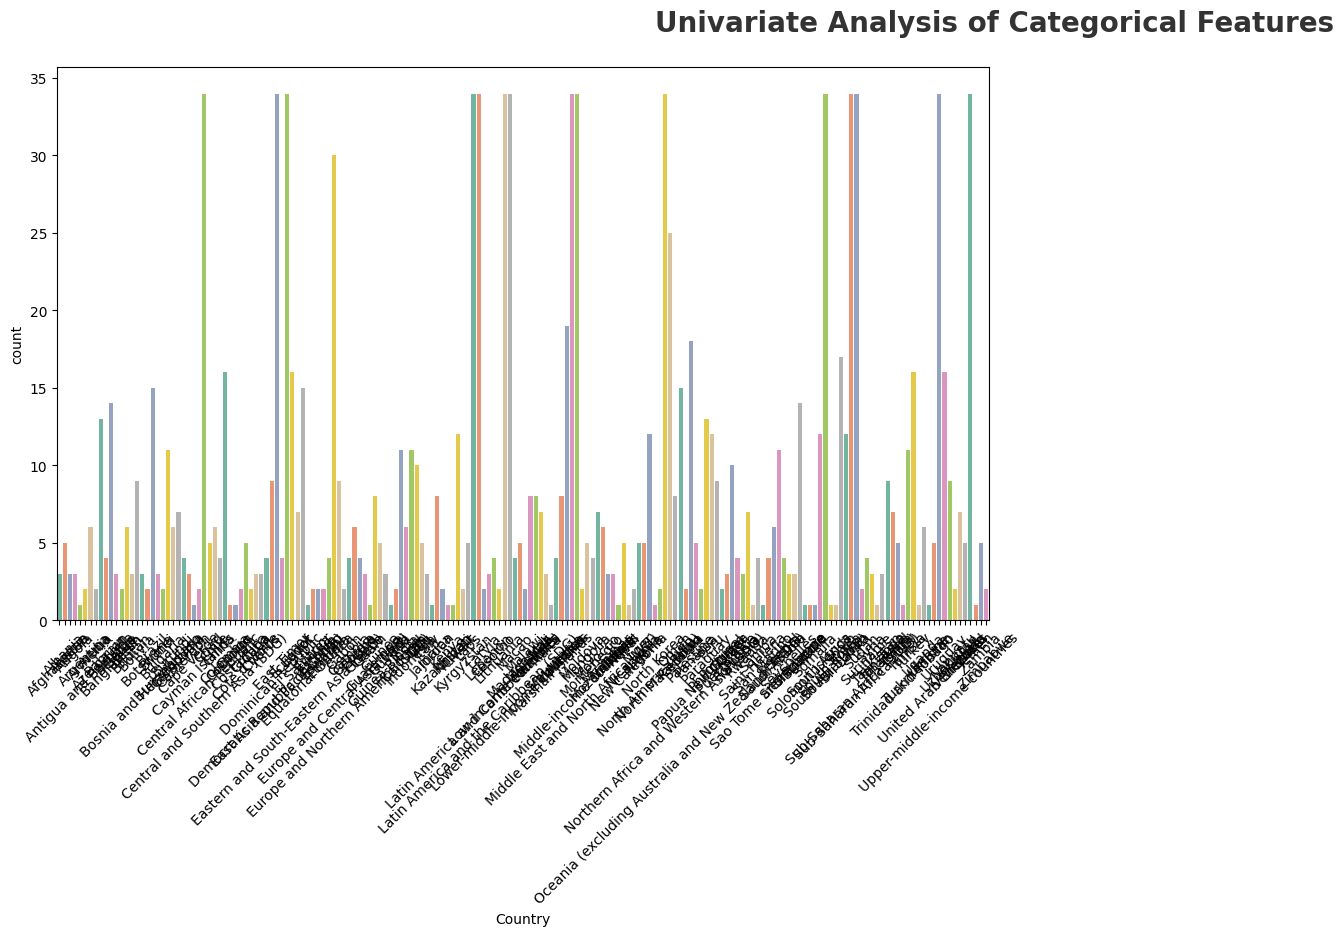

In [ ]:
# categorical columns
plt.figure(figsize=(20, 15))
plt.suptitle('Univariate Analysis of Categorical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)
category = ['Country']
for i in range(0, len(category)):
    plt.subplot(2, 2, i+1)
    sns.countplot(x=df_illiterate_world_population[category[i]],palette="Set2")
    plt.xlabel(category[i])
    plt.xticks(rotation=45)
    plt.tight_layout()

In [ ]:
cols = ['illiteracy_rate', 'literacy_rate']

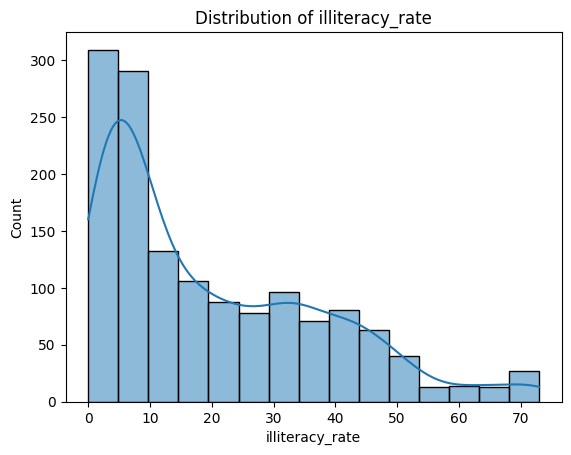

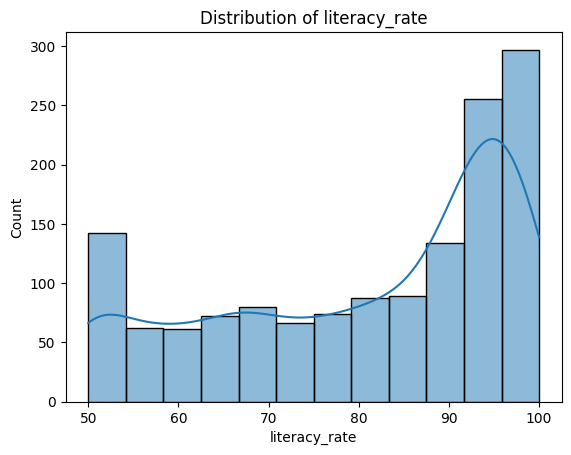

In [ ]:
for col in cols:
    plt.figure()
    sns.histplot(df_illiterate_world_population[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

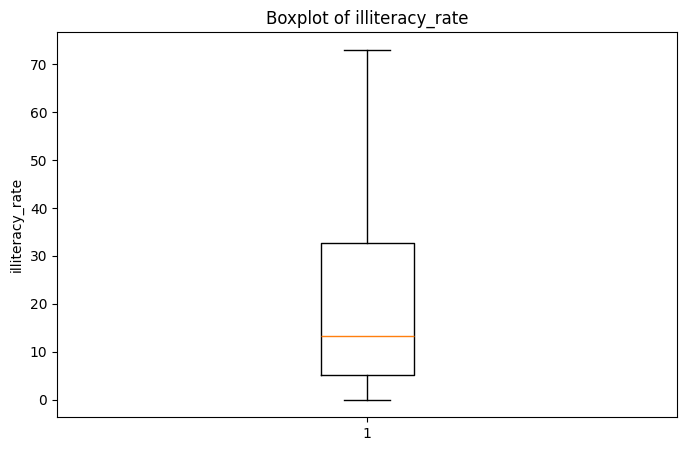

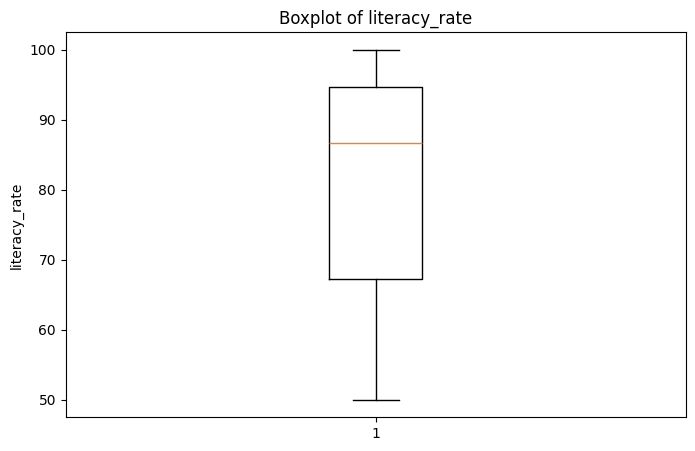

In [ ]:
cols = ["illiteracy_rate","literacy_rate"]

for i in range(0, 2):
    plt.figure(figsize=(8, 5))
    plt.boxplot(df_illiterate_world_population[cols[i]])
    plt.title(f"Boxplot of {cols[i]}")
    plt.ylabel(cols[i])
    plt.show()


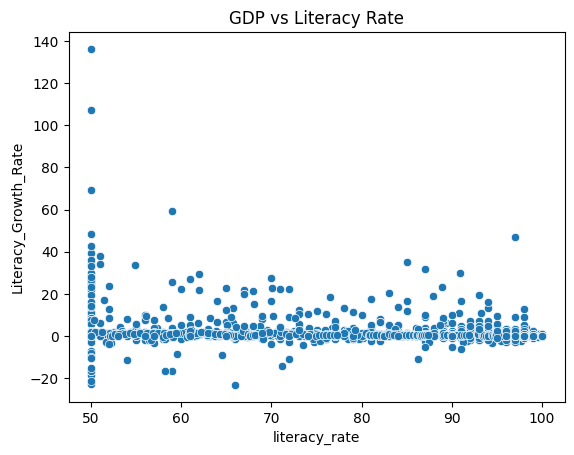

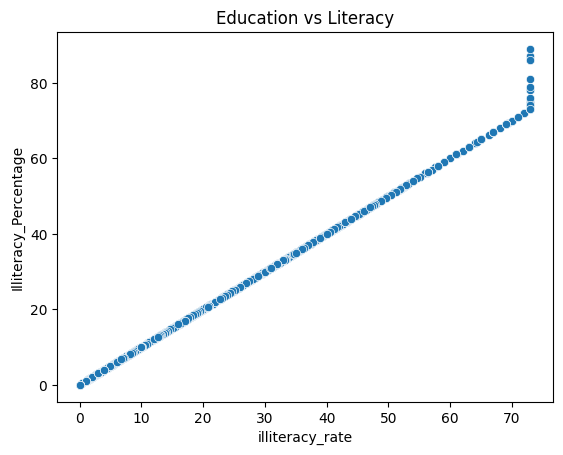

In [ ]:
# GDP vs Literacy
plt.figure()
corr = df_illiterate_world_population[cols].corr()
sns.scatterplot(x='literacy_rate', y='Literacy_Growth_Rate', data = df_illiterate_world_population)
plt.title("GDP vs Literacy Rate")
plt.show()

# Education vs Literacy
plt.figure()
sns.scatterplot(x='illiteracy_rate', y='Illiteracy_Percentage', data = df_illiterate_world_population)

plt.title("Education vs Literacy")
plt.show()

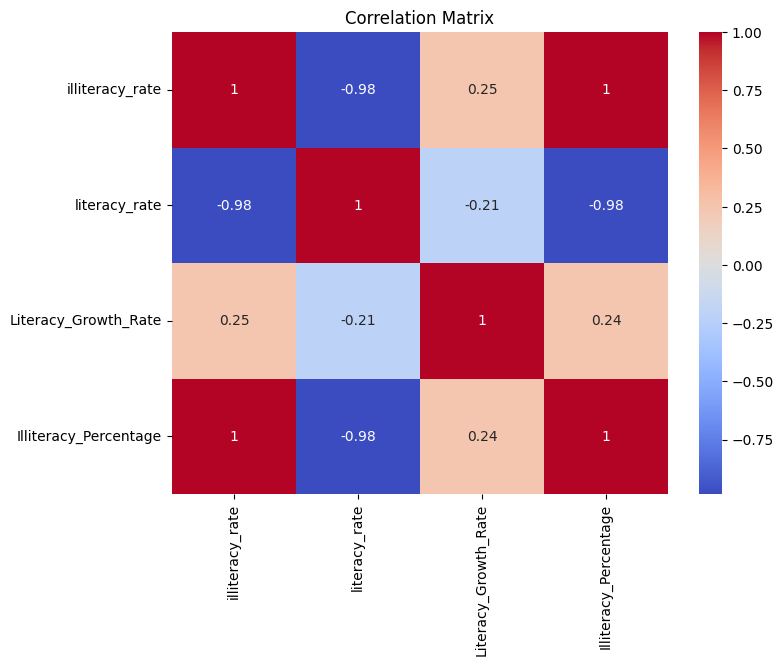

In [ ]:
cols = ["illiteracy_rate"	, "literacy_rate"	,"Literacy_Growth_Rate", "Illiteracy_Percentage"]
corr = df_illiterate_world_population[cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


In [ ]:
import pandas as pd
df_gdp_per_capita = pd.read_csv("https://ourworldindata.org/grapher/gdp-per-capita-worldbank.csv?v=1&csvType=full&useColumnShortNames=true",storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})
df_gdp_per_capita = df_gdp_per_capita.loc[(df_gdp_per_capita['year'] >= 1990) & (df_gdp_per_capita['year'] <= 2023)]
df_gdp_per_capita.head()

,entity,code,year,ny_gdp_pcap_pp_kd,owid_region
0,Afghanistan,AFG,2000,1617.8264,Asia
1,Afghanistan,AFG,2001,1454.1108,Asia
2,Afghanistan,AFG,2002,1774.3087,Asia
3,Afghanistan,AFG,2003,1815.9282,Asia
4,Afghanistan,AFG,2004,1776.9182,Asia


In [ ]:
df_gdp_per_capita = df_gdp_per_capita.loc[(df_gdp_per_capita['year'] >= 1990) & (df_gdp_per_capita['year'] <= 2023)]
df_gdp_per_capita = df_gdp_per_capita.rename(columns={'entity': 'Country'})
df_gdp_per_capita = df_gdp_per_capita.rename(columns={'ny_gdp_pcap_pp_kd' : 'GDP_Per_Capita'})
df_gdp_per_capita = df_gdp_per_capita.drop(columns = ['code'])
df_gdp_per_capita['owid_region'].fillna('Unknown', inplace=True)

In [ ]:
df_gdp_per_capita.head()

,Country,year,GDP_Per_Capita,owid_region
0,Afghanistan,2000,1617.8264,Asia
1,Afghanistan,2001,1454.1108,Asia
2,Afghanistan,2002,1774.3087,Asia
3,Afghanistan,2003,1815.9282,Asia
4,Afghanistan,2004,1776.9182,Asia


In [ ]:
df_gdp_per_capita.isnull().sum()

,0
Country,0
year,0
GDP_Per_Capita,0
owid_region,0


In [ ]:
import pandas as pd

df_average_years_schooling = pd.read_csv("https://ourworldindata.org/grapher/literacy-rates-vs-average-years-of-schooling.csv?v=1&csvType=full&useColumnShortNames=true",storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})

df_average_years_schooling.head()
df_average_years_schooling

,entity,code,year,literacy_rate,mf_youth_and_adults__15_64_years__average_years_of_education,population_historical,owid_region
0,Afghanistan,AFG,1870,NaN,0.01,4101170.0,Asia
1,Afghanistan,AFG,1875,NaN,0.01,4193635.0,Asia
2,Afghanistan,AFG,1880,NaN,0.01,4288021.0,Asia
3,Afghanistan,AFG,1885,NaN,0.01,4384343.0,Asia
4,Afghanistan,AFG,1890,NaN,0.01,4482635.0,Asia
...,...,...,...,...,...,...,...
5360,Zimbabwe,ZWE,2005,NaN,7.65,12483433.0,Africa
5361,Zimbabwe,ZWE,2010,NaN,7.86,13356551.0,Africa
5362,Zimbabwe,ZWE,2015,NaN,8.03,14399008.0,Africa
5363,Zimbabwe,ZWE,2019,93.22755,NaN,15271377.0,Africa


In [ ]:
df_average_years_schooling = df_average_years_schooling.loc[(df_average_years_schooling['year'] >= 1990) & (df_average_years_schooling['year'] <= 2023)]
df_average_years_schooling = df_average_years_schooling.rename(columns={'entity': 'Country'})
df_average_years_schooling = df_average_years_schooling.rename(columns={'mf_youth_and_adults__15_64_years__average_years_of_education' : 'Average_years_of_education_15_64'})
df_average_years_schooling = df_average_years_schooling.drop(columns = ['code'])

In [ ]:
df_average_years_schooling.head()

,Country,year,literacy_rate,Average_years_of_education_15_64,population_historical,owid_region
25,Afghanistan,1990,NaN,2.06,12045664.0,Asia
26,Afghanistan,1995,NaN,2.40,17065837.0,Asia
27,Afghanistan,2000,NaN,3.03,20130334.0,Asia
28,Afghanistan,2005,NaN,3.32,24404575.0,Asia
29,Afghanistan,2010,NaN,3.93,28284088.0,Asia


In [ ]:
df_average_years_schooling.isnull().sum()

,0
Country,0
year,0
literacy_rate,751
Average_years_of_education_15_64,1252
population_historical,450
owid_region,589


In [ ]:
df_average_years_schooling['owid_region'].fillna('Unknown', inplace=True)

In [ ]:
# Fill literacy rate
df_average_years_schooling['literacy_rate'].fillna(df_average_years_schooling['literacy_rate'].mean(), inplace = True)
# Fill education
df_average_years_schooling['Average_years_of_education_15_64'].fillna(df_average_years_schooling['Average_years_of_education_15_64'].mean(), inplace = True)
#Fill population
df_average_years_schooling['population_historical'].fillna(df_average_years_schooling['population_historical'].mean(), inplace=True)

In [ ]:
df_average_years_schooling.isnull().sum()

,0
Country,0
year,0
literacy_rate,0
Average_years_of_education_15_64,0
population_historical,0
owid_region,0


In [ ]:
gdp_schooling   = pd.merge(df_gdp_per_capita, df_average_years_schooling, on=['Country', 'year'], how='inner')
gdp_schooling.head()

,Country,year,GDP_Per_Capita,owid_region_x,literacy_rate,Average_years_of_education_15_64,population_historical,owid_region_y
0,Afghanistan,2000,1617.8264,Asia,79.929307,3.030000,20130334.0,Asia
1,Afghanistan,2005,1908.1147,Asia,79.929307,3.320000,24404575.0,Asia
2,Afghanistan,2010,2848.5862,Asia,79.929307,3.930000,28284088.0,Asia
3,Afghanistan,2011,2757.0525,Asia,31.000000,8.190541,29347708.0,Asia
4,Afghanistan,2015,2967.6921,Asia,33.753840,4.810000,33831767.0,Asia


In [ ]:
df_literacy.to_csv("df_literacy.csv")

In [ ]:
gdp_schooling['owid_region_y'].fillna('Unknown', inplace=True)
# Merge columns
gdp_schooling['owid_region'] = gdp_schooling['owid_region_x'].combine_first(gdp_schooling['owid_region_y'])
# Drop old columns
gdp_schooling.drop(columns=['owid_region_x', 'owid_region_y'], inplace=True)

In [ ]:
gdp_schooling.isnull().sum()

,0
Country,0
year,0
GDP_Per_Capita,0
literacy_rate,0
Average_years_of_education_15_64,0
population_historical,0
owid_region,0


In [ ]:
gdp_schooling.head()

,Country,year,GDP_Per_Capita,literacy_rate,Average_years_of_education_15_64,population_historical,owid_region
0,Afghanistan,2000,1617.8264,79.929307,3.030000,20130334.0,Asia
1,Afghanistan,2005,1908.1147,79.929307,3.320000,24404575.0,Asia
2,Afghanistan,2010,2848.5862,79.929307,3.930000,28284088.0,Asia
3,Afghanistan,2011,2757.0525,31.000000,8.190541,29347708.0,Asia
4,Afghanistan,2015,2967.6921,33.753840,4.810000,33831767.0,Asia


In [ ]:
gdp_schooling['Illiteracy_rate'] = 100 - gdp_schooling['literacy_rate']

In [ ]:
gdp_schooling['GDP_per_Schooling_Year'] = (gdp_schooling['GDP_Per_Capita'] / gdp_schooling['Average_years_of_education_15_64'])

In [ ]:
# Normalize literacy
gdp_schooling['Literacy_Index'] = gdp_schooling['literacy_rate'] / 100

# Normalize schooling (assuming max = 15 years)
gdp_schooling['Schooling_Index'] = gdp_schooling['Average_years_of_education_15_64'] / 15

# Create Education Index
gdp_schooling['Education_Index'] = (gdp_schooling['Literacy_Index'] + gdp_schooling['Schooling_Index']) / 2

In [ ]:
gdp_schooling.head()

,Country,year,GDP_Per_Capita,literacy_rate,Average_years_of_education_15_64,population_historical,owid_region,Illiteracy_rate,GDP_per_Schooling_Year,Literacy_Index,Schooling_Index,Education_Index
0,Afghanistan,2000,1617.8264,79.929307,3.030000,20130334.0,Asia,20.070693,533.936106,0.799293,0.202000,0.500647
1,Afghanistan,2005,1908.1147,79.929307,3.320000,24404575.0,Asia,20.070693,574.733343,0.799293,0.221333,0.510313
2,Afghanistan,2010,2848.5862,79.929307,3.930000,28284088.0,Asia,20.070693,724.831094,0.799293,0.262000,0.530647
3,Afghanistan,2011,2757.0525,31.000000,8.190541,29347708.0,Asia,69.000000,336.614219,0.310000,0.546036,0.428018
4,Afghanistan,2015,2967.6921,33.753840,4.810000,33831767.0,Asia,66.246160,616.983805,0.337538,0.320667,0.329103


In [ ]:
gdp_schooling.to_csv("gdp_schooling.csv")

In [ ]:
gdp_schooling.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1772 entries, 0 to 1771
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Country                           1772 non-null   object 
 1   year                              1772 non-null   int64  
 2   GDP_Per_Capita                    1772 non-null   float64
 3   literacy_rate                     1772 non-null   float64
 4   Average_years_of_education_15_64  1772 non-null   float64
 5   population_historical             1772 non-null   float64
 6   owid_region                       1772 non-null   object 
 7   Illiteracy_rate                   1772 non-null   float64
 8   GDP_per_Schooling_Year            1772 non-null   float64
 9   Literacy_Index                    1772 non-null   float64
 10  Schooling_Index                   1772 non-null   float64
 11  Education_Index                   1772 non-null   float64
dtypes: flo

In [ ]:
numeric_features = [feature for feature in gdp_schooling.columns if gdp_schooling[feature].dtype != 'O']
categorical_features = [feature for feature in gdp_schooling.columns if gdp_schooling[feature].dtype == 'O']

In [ ]:
# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 10 numerical features : ['year', 'GDP_Per_Capita', 'literacy_rate', 'Average_years_of_education_15_64', 'population_historical', 'Illiteracy_rate', 'GDP_per_Schooling_Year', 'Literacy_Index', 'Schooling_Index', 'Education_Index']

We have 2 categorical features : ['Country', 'owid_region']


In [ ]:
## Proportion of count data on categorical columns
for col in categorical_features:
    print(gdp_schooling[col].value_counts(normalize=True)*100)
    print('---------------------------')

Country
East Asia and Pacific (WB)       1.918736
Upper-middle-income countries    1.918736
Sub-Saharan Africa (WB)          1.918736
Low-income countries             1.918736
Lower-middle-income countries    1.918736
                                   ...   
Marshall Islands                 0.056433
Somalia                          0.056433
Solomon Islands                  0.056433
San Marino                       0.056433
Turkmenistan                     0.056433
Name: proportion, Length: 190, dtype: float64
---------------------------
owid_region
Asia             25.112867
Africa           22.629797
Unknown          15.801354
Europe           15.632054
North America     9.480813
South America     8.860045
Oceania           2.483070
Name: proportion, dtype: float64
---------------------------


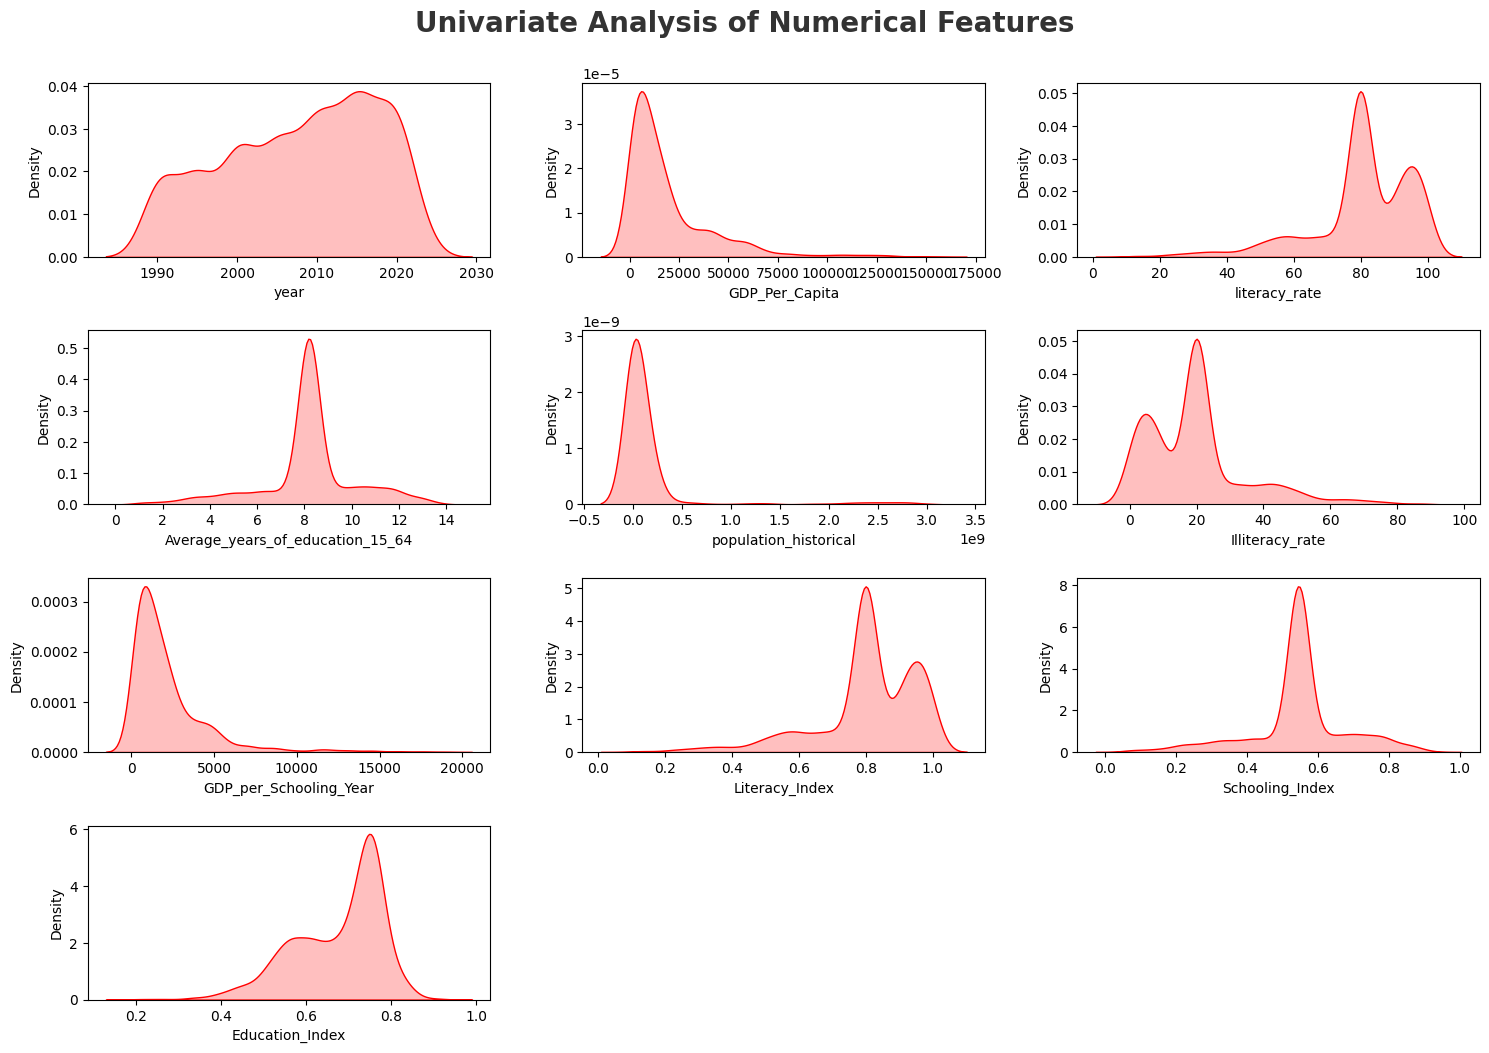

In [ ]:
#Proportion of count data on numerical columns
plt.figure(figsize=(15, 15))
plt.suptitle('Univariate Analysis of Numerical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(0, len(numeric_features)):
    plt.subplot(6, 3, i+1)
    sns.kdeplot(x=gdp_schooling[numeric_features[i]],shade=True, color='r')
    plt.xlabel(numeric_features[i])
    plt.tight_layout()


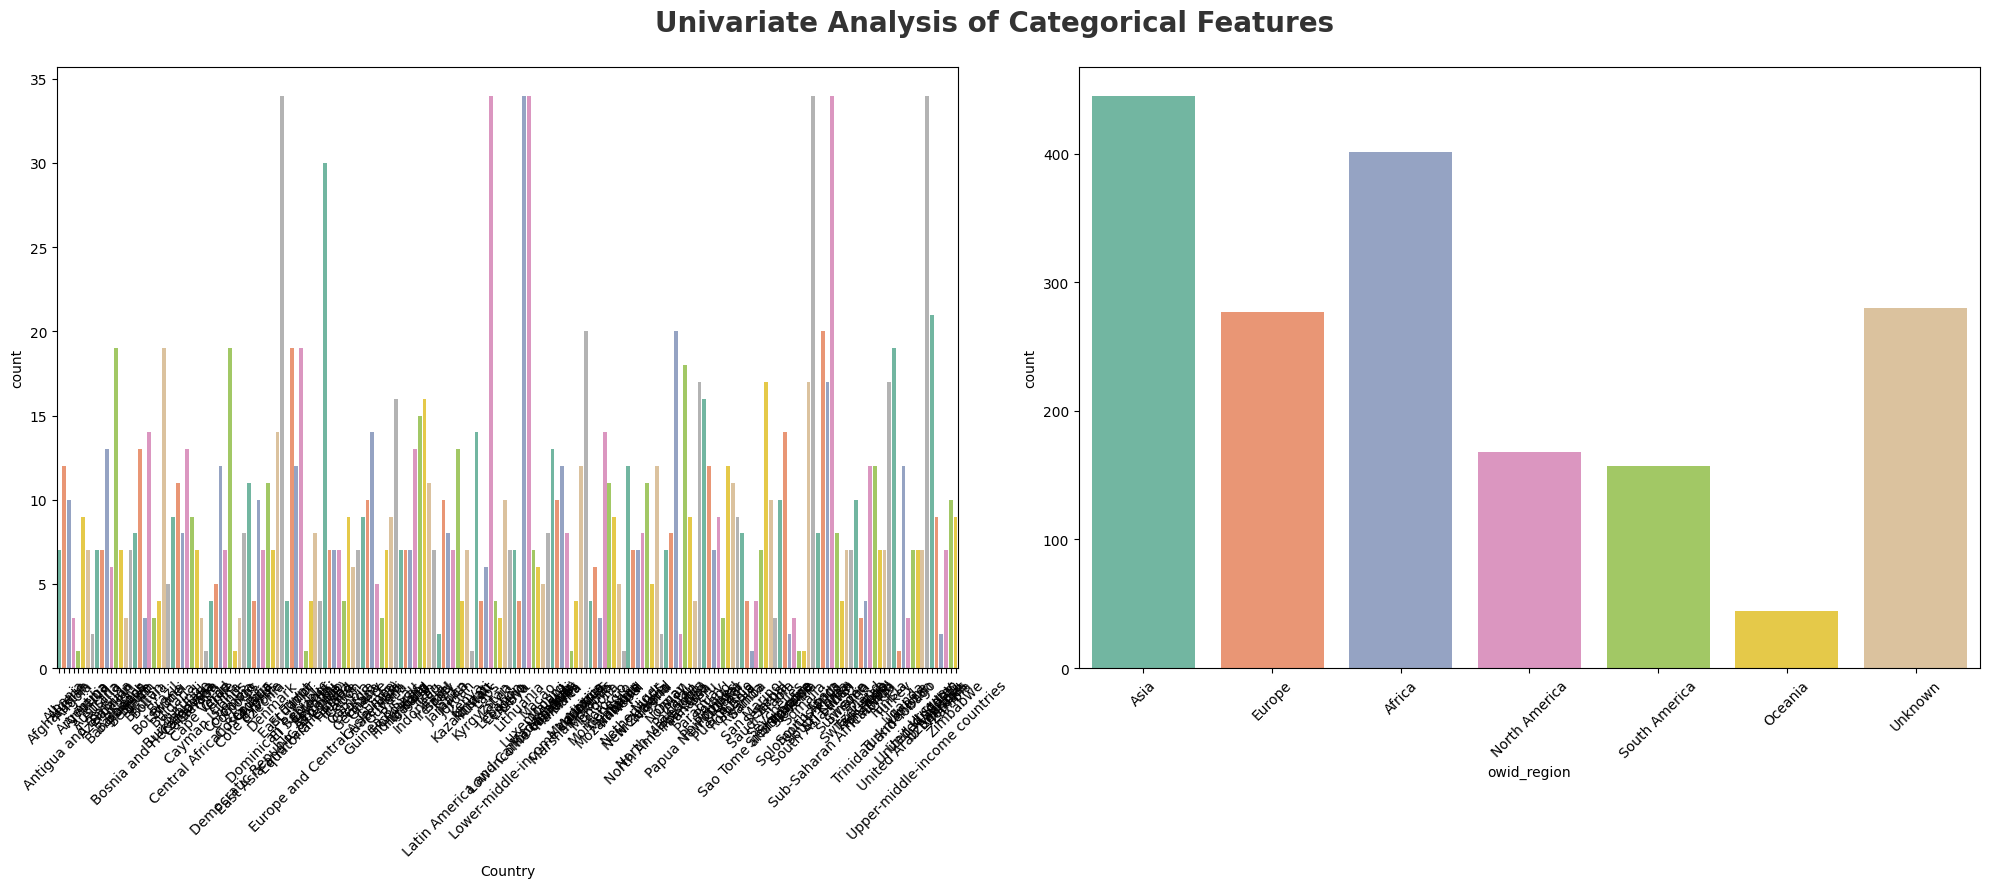

In [ ]:
# categorical columns
plt.figure(figsize=(20, 15))
plt.suptitle('Univariate Analysis of Categorical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)
category = ['Country', 'owid_region']
for i in range(0, len(category)):
    plt.subplot(2, 2, i+1)
    sns.countplot(x=gdp_schooling[category[i]],palette="Set2")
    plt.xlabel(category[i])
    plt.xticks(rotation=45)
    plt.tight_layout()

In [ ]:
df_average_years_schooling.to_csv("average_years_schooling.csv")

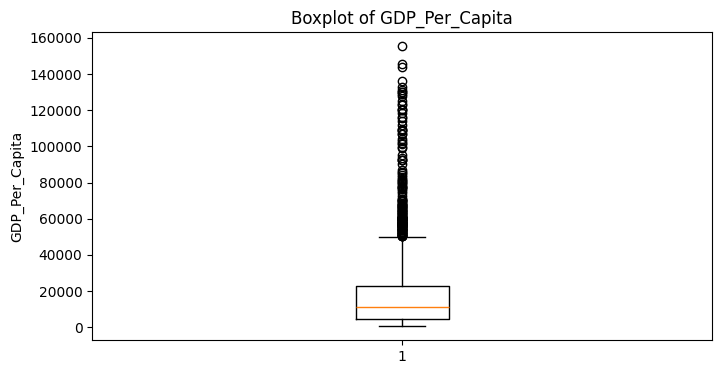

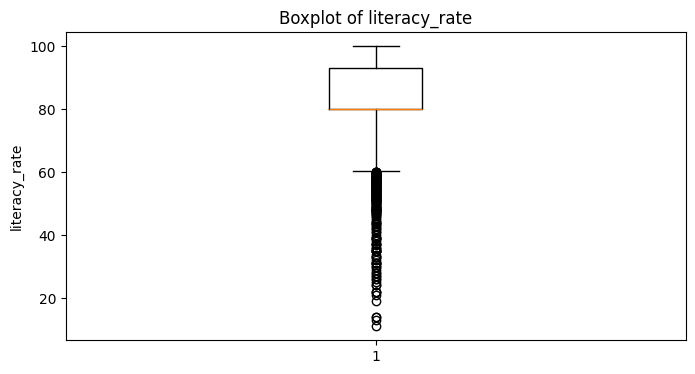

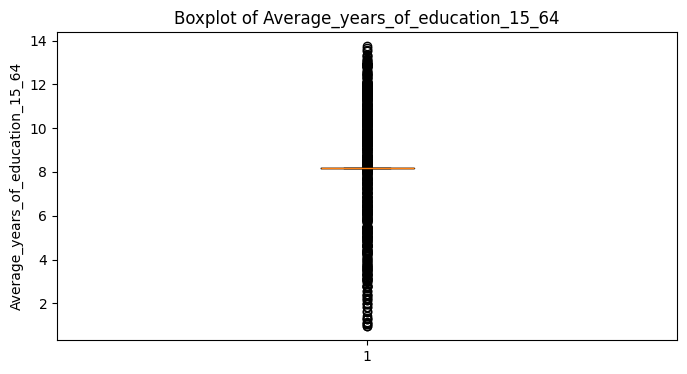

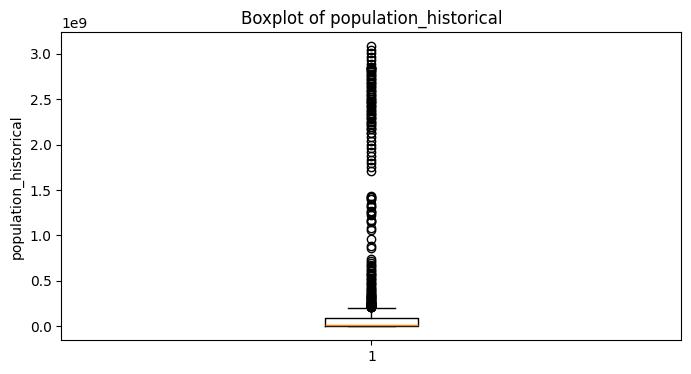

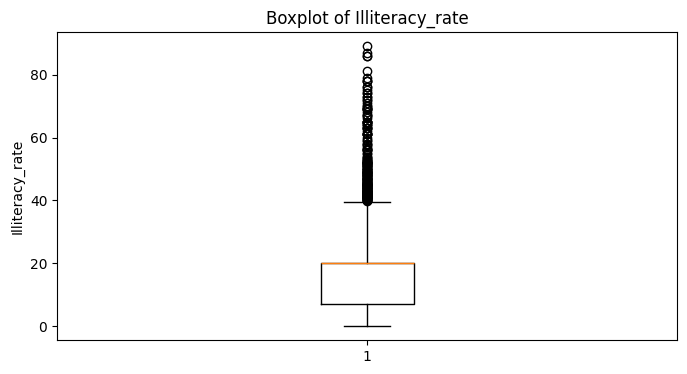

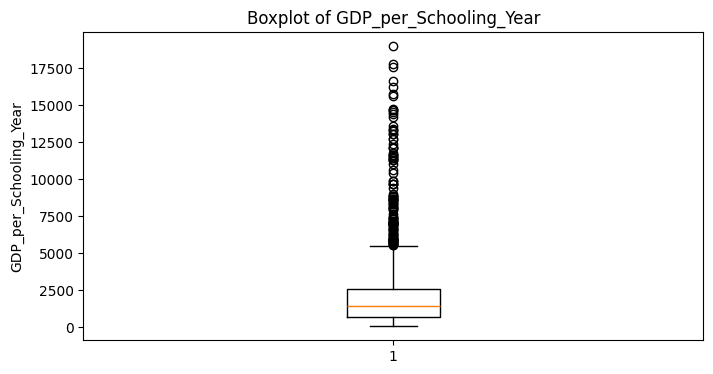

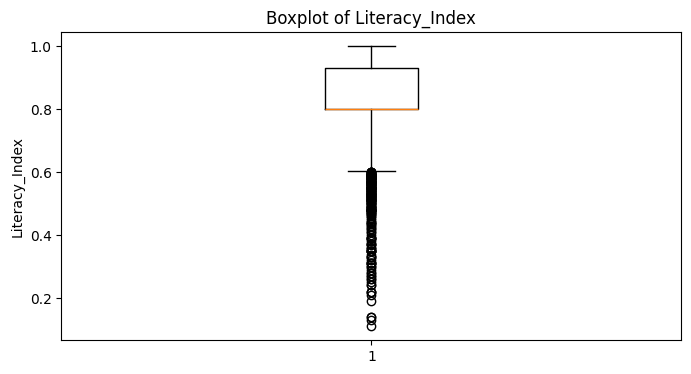

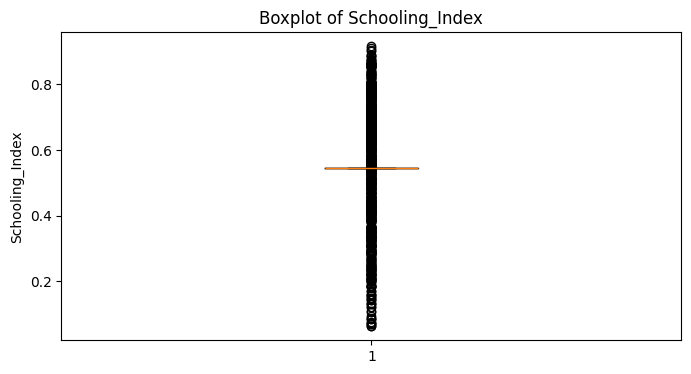

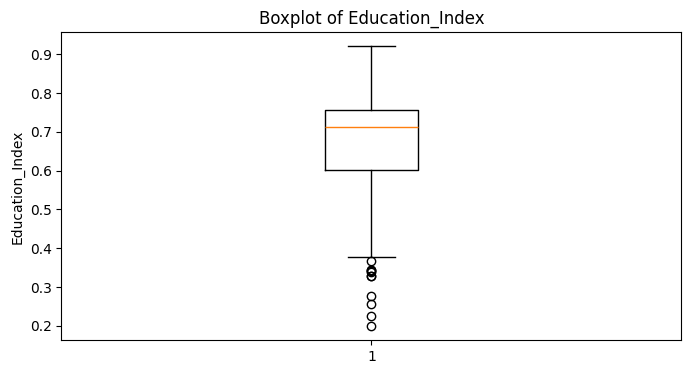

In [ ]:
import matplotlib.pyplot as plt
#cols = ['year','adult_literacy_rate', 'Youth_literacy_rate_male', 'Youth_literacy_rate_female', 'literacy_gender_gap', 'Youth_Literacy_Average']
cols = ['GDP_Per_Capita', 'literacy_rate', 'Average_years_of_education_15_64', 'population_historical', 'Illiteracy_rate', 'GDP_per_Schooling_Year', 'Literacy_Index', 'Schooling_Index', 'Education_Index']
for i in range(0, 9):
    plt.figure(figsize=(8, 4))
    plt.boxplot(gdp_schooling[cols[i]])
    plt.title(f"Boxplot of {cols[i]}")
    plt.ylabel(cols[i])
    plt.show()

In [ ]:
cols = ['GDP_Per_Capita', 'literacy_rate', 'Average_years_of_education_15_64', 'population_historical']
#cols = ['population_historical']

for col in cols:
    Q1 = gdp_schooling[col].quantile(0.25)
    Q3 = gdp_schooling[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = gdp_schooling[(gdp_schooling[col] < lower) |
                             (gdp_schooling[col] > upper)]

    print(f"\n🔎 Outliers in {col}: {len(outliers)}")


🔎 Outliers in GDP_Per_Capita: 164

🔎 Outliers in literacy_rate: 201

🔎 Outliers in Average_years_of_education_15_64: 809

🔎 Outliers in population_historical: 153


In [ ]:
'''gdp_schooling['GDP_Per_Capita'] = gdp_schooling['GDP_Per_Capita'].clip(upper = 50000)

gdp_schooling['literacy_rate'] = gdp_schooling['literacy_rate'].clip(lower=250)
gdp_schooling['Average_years_of_education_15_64'] = gdp_schooling['Average_years_of_education_15_64'].clip(lower=0)

gdp_schooling['population_historical'] = gdp_schooling['population_historical'].clip(upper=15)
gdp_schooling['population_historical'] = gdp_schooling['population_historical'].clip(lower=10)'''

"gdp_schooling['GDP_Per_Capita'] = gdp_schooling['GDP_Per_Capita'].clip(upper = 50000)\n\ngdp_schooling['literacy_rate'] = gdp_schooling['literacy_rate'].clip(lower=250)\ngdp_schooling['Average_years_of_education_15_64'] = gdp_schooling['Average_years_of_education_15_64'].clip(lower=0)\n\ngdp_schooling['population_historical'] = gdp_schooling['population_historical'].clip(upper=15)\ngdp_schooling['population_historical'] = gdp_schooling['population_historical'].clip(lower=10)"

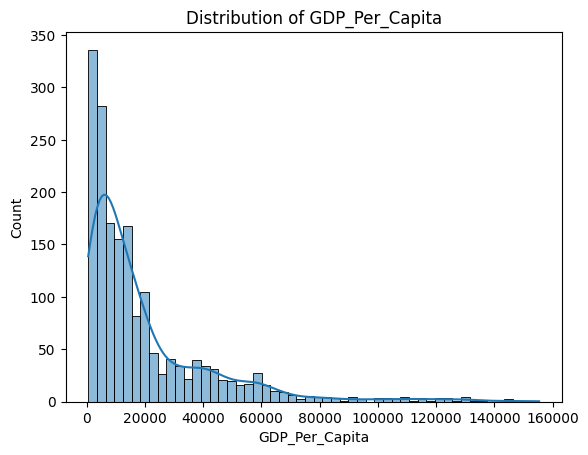

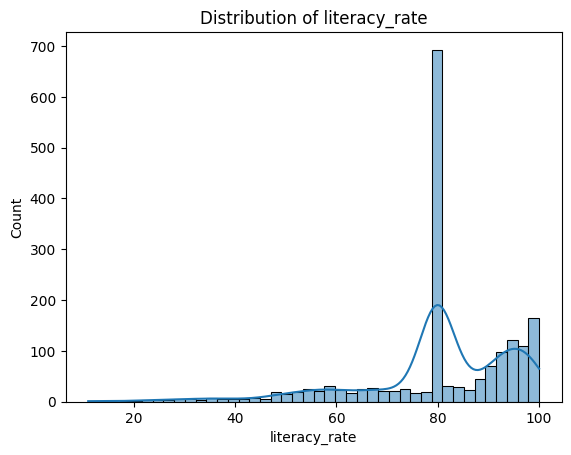

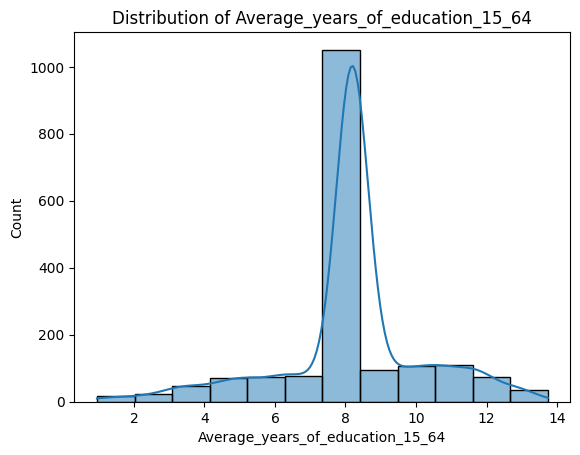

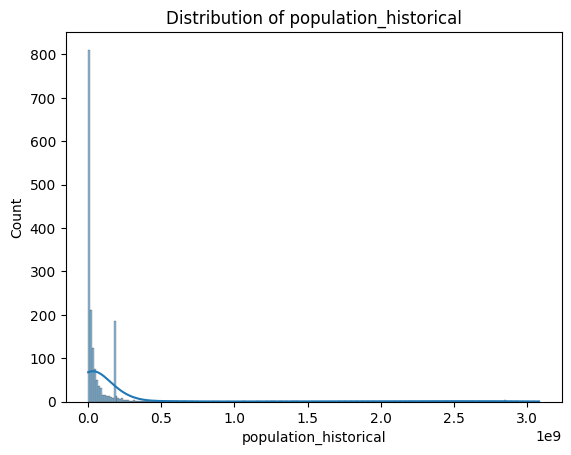

In [ ]:
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
for col in cols:
    plt.figure()
    sns.histplot(gdp_schooling[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

In [ ]:
#cols = ['GDP_Per_Capita',	'literacy_rate',	'Average_years_of_education_15_64',	'population_historical',	'owid_region']
#cols = ['owid_region']
#Country	year	GDP_Per_Capita	literacy_rate	Average_years_of_education_15_64	population_historical	owid_region

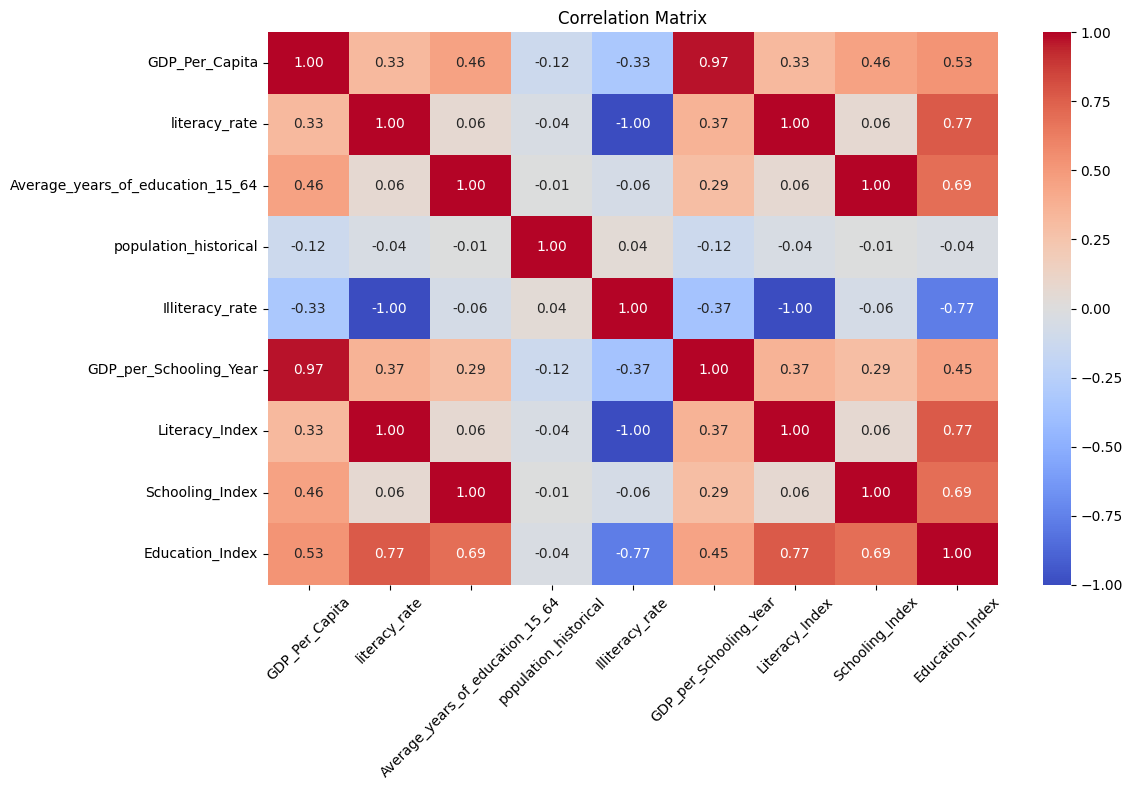

In [ ]:
cols = ['GDP_Per_Capita', 'literacy_rate','Average_years_of_education_15_64', 'population_historical', 'Illiteracy_rate', 'GDP_per_Schooling_Year', 'Literacy_Index', 'Schooling_Index', 'Education_Index']
corr_matrix = gdp_schooling[cols].corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Matrix")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()



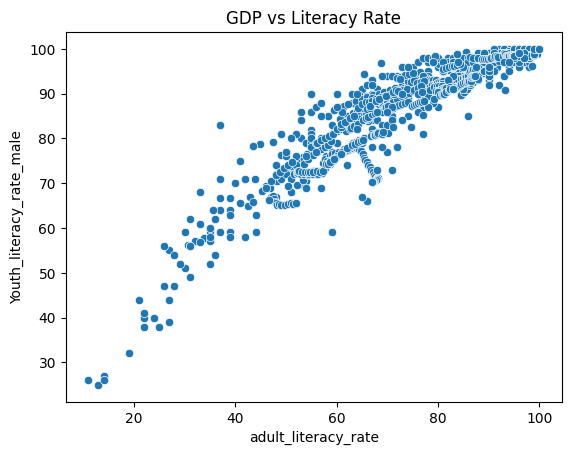

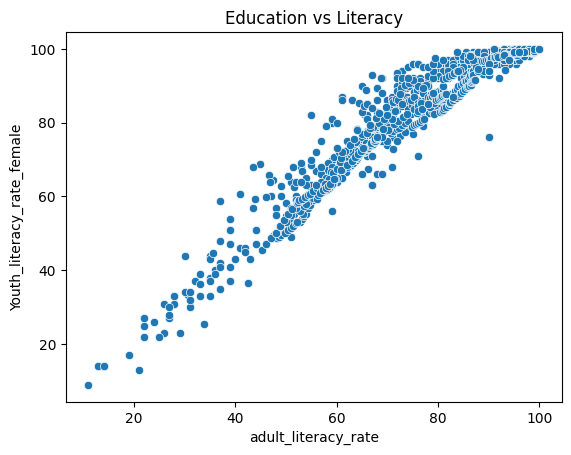

In [ ]:

# GDP vs Literacy
plt.figure()
sns.scatterplot(x='adult_literacy_rate', y='Youth_literacy_rate_male', data=df_literacy)
plt.title("GDP vs Literacy Rate")
plt.show()

# Education vs Literacy
plt.figure()
sns.scatterplot(x='adult_literacy_rate', y='Youth_literacy_rate_female', data=df_literacy)
plt.title("Education vs Literacy")
plt.show()

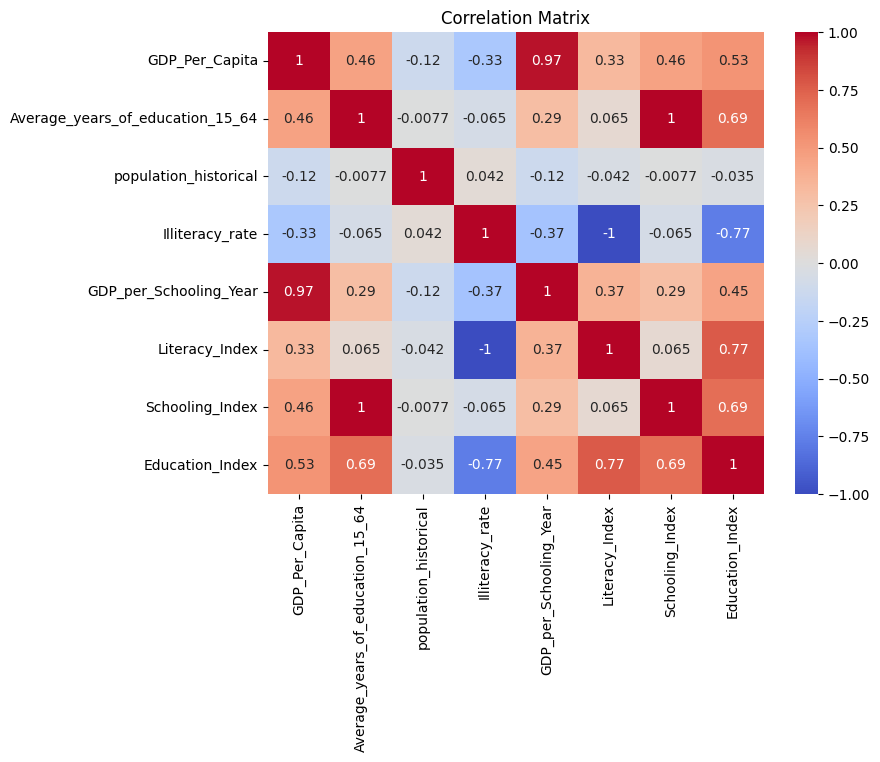

In [ ]:
#cols = ['adult_literacy_rate', 'Youth_literacy_rate_male', 'Youth_literacy_rate_female']
cols = ['GDP_Per_Capita', 'Average_years_of_education_15_64', 'population_historical', 'Illiteracy_rate', 'GDP_per_Schooling_Year', 'Literacy_Index', 'Schooling_Index', 'Education_Index']
corr = gdp_schooling[cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


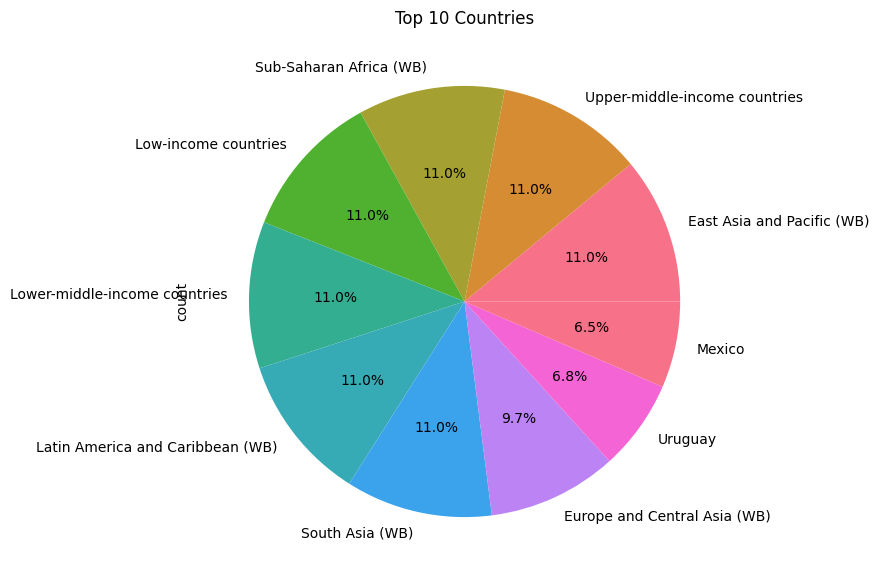

In [ ]:
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
plt.figure(figsize=(10,7))
plt.title('Top 10 Countries')
colors = sns.color_palette("husl", 9)
gdp_schooling["Country"].value_counts().nlargest(n=10).plot.pie(autopct='%1.1f%%',figsize=(10,7), colors=colors)
plt.show()

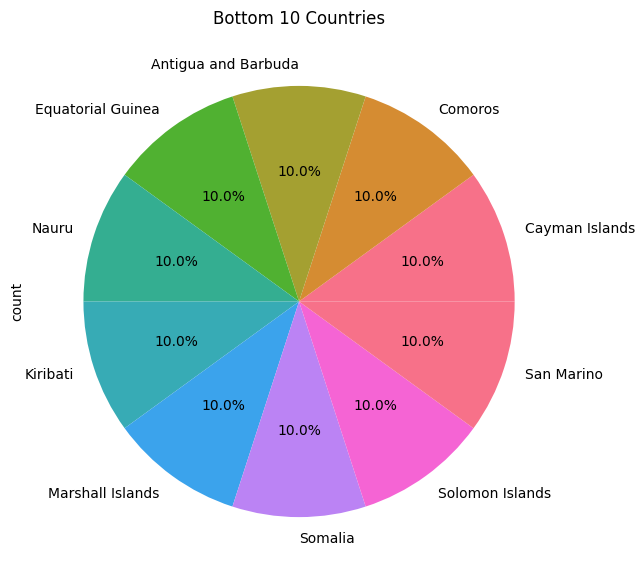

In [ ]:
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
plt.figure(figsize=(10,7))
plt.title('Bottom 10 Countries')
colors = sns.color_palette("husl", 9)
gdp_schooling["Country"].value_counts().nsmallest(n=10).plot.pie(autopct='%1.1f%%',figsize=(10,7), colors=colors)
plt.show()

In [ ]:
!pip install pymysql

In [ ]:
# If you are using colab use sqlite3
import sqlite3
conn = sqlite3.connect("GLE.db")
cursor = conn.cursor()

In [ ]:
df_literacy.to_sql("literacy ",if_exists="replace",con = conn)

1405

In [ ]:
df_illiterate_world_population.to_sql("illiteracy ",if_exists="replace",con = conn)

1419

In [ ]:
cursor.execute(''' CREATE TABLE IF NOT EXISTS literacy_rates (
    Country TEXT,
    year INTEGER,
    adult_literacy_rate REAL,
    Youth_literacy_rate_male REAL,
    Youth_literacy_rate_female REAL,
    owid_region TEXT,
    literacy_gender_gap REAL,
    Youth_Literacy_Average REAL
);''')

In [ ]:
data = list(df_literacy.itertuples(index=False, name=None))

In [ ]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('GLE.db')
cursor = conn.cursor()
query = "INSERT INTO literacy_rates (Country, year, adult_literacy_rate, Youth_literacy_rate_male, Youth_literacy_rate_female, owid_region, literacy_gender_gap, Youth_Literacy_Average) VALUES (?,?,?,?,?,?,?,?)"
cursor.executemany(query, data)
conn.commit()
conn.close()


In [ ]:
import sqlite3
import pandas as pd
conn = sqlite3.connect("GLE.db")
df = pd.read_sql("SELECT * from literacy_rates", conn)
df

,Country,year,adult_literacy_rate,Youth_literacy_rate_male,Youth_literacy_rate_female,owid_region,literacy_gender_gap,Youth_Literacy_Average
0,Afghanistan,2011,31.00000,62.00000,32.00000,Asia,30.00000,47.000000
1,Afghanistan,2015,33.75384,57.73505,25.48416,Asia,32.25089,41.609605
2,Afghanistan,2021,37.00000,71.00000,42.00000,Asia,29.00000,56.500000
3,Albania,2001,99.00000,99.00000,99.00000,Europe,0.00000,99.000000
4,Albania,2008,96.00000,99.00000,99.00000,Europe,0.00000,99.000000
...,...,...,...,...,...,...,...,...
7020,Zambia,2002,69.00000,78.00000,66.00000,Africa,12.00000,72.000000
7021,Zambia,2010,83.00000,91.00000,87.00000,Africa,4.00000,89.000000
7022,Zambia,2018,71.13230,82.44786,72.90992,Africa,9.53794,77.678890
7023,Zimbabwe,1992,84.00000,97.00000,94.00000,Africa,3.00000,95.500000


In [ ]:
import sqlite3
conn = sqlite3.connect("GLE.db")
cursor = conn.cursor()

In [ ]:
cursor.execute('''CREATE TABLE IF NOT EXISTS illiteracy_population (
    Country TEXT,
    year INTEGER,
    illiteracy_rate REAL,
    literacy_rate REAL,
    Literacy_Growth_Rate REAL,
    Illiteracy_Percentage REAL
);''')

In [ ]:
data = list(df_illiterate_world_population.itertuples(index=False, name=None))

In [ ]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('GLE.db')
cursor = conn.cursor()
query = "INSERT INTO illiteracy_population (Country, year, illiteracy_rate, literacy_rate, Literacy_Growth_Rate, Illiteracy_Percentage) VALUES (?,?,?,?,?,?)"
cursor.executemany(query, data)
conn.commit()
conn.close()

In [ ]:
import sqlite3
import pandas as pd
conn = sqlite3.connect("GLE.db")
df = pd.read_sql("SELECT * from illiteracy_population", conn)
df

,Country,year,illiteracy_rate,literacy_rate,Literacy_Growth_Rate,Illiteracy_Percentage
0,Afghanistan,2011,69.000000,50.00000,0.000000,69.00000
1,Afghanistan,2015,66.246155,50.00000,8.883355,66.24616
2,Afghanistan,2021,63.000000,50.00000,9.617158,63.00000
3,Albania,2001,1.000000,99.00000,0.000000,1.00000
4,Albania,2008,4.000000,96.00000,-3.030303,4.00000
...,...,...,...,...,...,...
7090,Zambia,2002,31.000000,69.00000,1.470588,31.00000
7091,Zambia,2010,17.000000,83.00000,20.289855,17.00000
7092,Zambia,2018,28.867699,71.13230,-14.298434,28.86770
7093,Zimbabwe,1992,16.000000,84.00000,0.000000,16.00000


In [ ]:
import sqlite3
conn = sqlite3.connect("GLE.db")
cursor = conn.cursor()

In [ ]:
cursor.execute(''' CREATE TABLE IF NOT EXISTS gdp_schoolings (
    Country TEXT,
    year INTEGER,
    GDP_Per_Capita REAL,
    literacy_rate REAL,
    Average_years_of_education_15_64 REAL,
    population_historical REAL,
    owid_region TEXT,
    Illiteracy_rate,
    GDP_per_Schooling_Year REAL,
    Literacy_Index REAL,
    Schooling_Index	REAL,
    Education_Index REAL)''')

In [ ]:
data = list(gdp_schooling.itertuples(index=False, name=None))

In [ ]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('GLE.db')
cursor = conn.cursor()
# Insert query
query = "INSERT INTO gdp_schoolings (Country, year,GDP_Per_Capita, literacy_rate, Average_years_of_education_15_64, population_historical, owid_region, Illiteracy_rate,GDP_per_Schooling_Year,Literacy_Index,	Schooling_Index, Education_Index) VALUES (?,?,?,?,?,?,?,?,?,?,?,?)"
#query = "INSERT INTO Crypto_price (coin_id, date, price_usd) VALUES (?, ?,?)"

# Bulk insert
cursor.executemany(query, data)

# Commit changes
conn.commit()
conn.close()


In [ ]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("GLE.db")
df = pd.read_sql("SELECT Country, year,GDP_Per_Capita, literacy_rate, Average_years_of_education_15_64, population_historical, owid_region, Illiteracy_rate,GDP_per_Schooling_Year,Literacy_Index,Schooling_Index, Education_Index FROM gdp_schoolings", con = conn)
df

,Country,year,GDP_Per_Capita,literacy_rate,Average_years_of_education_15_64,population_historical,owid_region,Illiteracy_rate,GDP_per_Schooling_Year,Literacy_Index,Schooling_Index,Education_Index
0,Afghanistan,2000,1617.8264,79.929307,3.030000,20130334.0,Asia,20.070693,533.936106,0.799293,0.202000,0.500647
1,Afghanistan,2005,1908.1147,79.929307,3.320000,24404575.0,Asia,20.070693,574.733343,0.799293,0.221333,0.510313
2,Afghanistan,2010,2848.5862,79.929307,3.930000,28284088.0,Asia,20.070693,724.831094,0.799293,0.262000,0.530647
3,Afghanistan,2011,2757.0525,31.000000,8.190541,29347708.0,Asia,69.000000,336.614219,0.310000,0.546036,0.428018
4,Afghanistan,2015,2967.6921,33.753840,4.810000,33831767.0,Asia,66.246160,616.983805,0.337538,0.320667,0.329103
...,...,...,...,...,...,...,...,...,...,...,...,...
8855,Zimbabwe,2005,4004.6646,79.929307,7.650000,12483433.0,Africa,20.070693,523.485569,0.799293,0.510000,0.654647
8856,Zimbabwe,2010,3885.3938,79.929307,7.860000,13356551.0,Africa,20.070693,494.324911,0.799293,0.524000,0.661647
8857,Zimbabwe,2015,5102.7144,79.929307,8.030000,14399008.0,Africa,20.070693,635.456339,0.799293,0.535333,0.667313
8858,Zimbabwe,2019,4993.8438,93.227550,8.190541,15271377.0,Africa,6.772450,609.708677,0.932275,0.546036,0.739156


# **SQL Queries**

literacy_rates

In [ ]:
import sqlite3
conn = sqlite3.connect("GLE.db")
cursor = conn.cursor()

In [ ]:
df = pd.read_sql("SELECT Country, adult_literacy_rate FROM literacy_rates WHERE year = 2020 ORDER BY adult_literacy_rate DESC LIMIT 5", con = conn)
df

,Country,adult_literacy_rate
0,Armenia,100.0
1,Armenia,100.0
2,Armenia,100.0
3,Armenia,100.0
4,Armenia,100.0


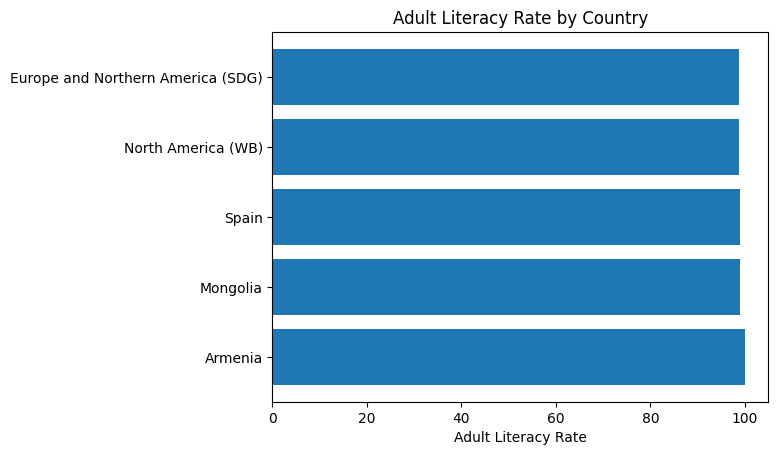

In [ ]:
import matplotlib.pyplot as plt

countries = ["Armenia", "Mongolia", "Spain",
             "North America (WB)",
             "Europe and Northern America (SDG)"]

rates = [100, 99, 99, 98.77, 98.67]

plt.barh(countries, rates)
plt.xlabel("Adult Literacy Rate")
plt.title("Adult Literacy Rate by Country")
plt.show()

In [ ]:
df = pd.read_sql("SELECT Country,year,adult_literacy_rate,Youth_literacy_rate_male,Youth_literacy_rate_female,owid_region,literacy_gender_gap,Youth_Literacy_Average FROM literacy_rates WHERE Youth_literacy_rate_female < 80;", conn)
df

,Country,year,adult_literacy_rate,Youth_literacy_rate_male,Youth_literacy_rate_female,owid_region,literacy_gender_gap,Youth_Literacy_Average
0,Afghanistan,2011,31.00000,62.00000,32.00000,Asia,30.00000,47.000000
1,Afghanistan,2015,33.75384,57.73505,25.48416,Asia,32.25089,41.609605
2,Afghanistan,2021,37.00000,71.00000,42.00000,Asia,29.00000,56.500000
3,Angola,2001,67.00000,84.00000,63.00000,Africa,21.00000,73.500000
4,Angola,2014,66.00000,85.00000,71.00000,Africa,14.00000,78.000000
...,...,...,...,...,...,...,...,...
1985,Yemen,1994,37.00000,83.00000,35.00000,Asia,48.00000,59.000000
1986,Zambia,1990,65.00000,67.00000,66.00000,Africa,1.00000,66.500000
1987,Zambia,1999,68.00000,73.00000,66.00000,Africa,7.00000,69.500000
1988,Zambia,2002,69.00000,78.00000,66.00000,Africa,12.00000,72.000000


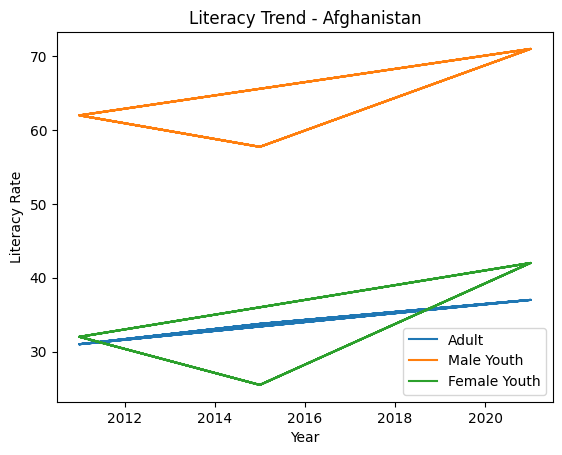

In [ ]:
df = pd.read_sql("SELECT Country,year,adult_literacy_rate,Youth_literacy_rate_male,Youth_literacy_rate_female,owid_region,literacy_gender_gap,Youth_Literacy_Average FROM literacy_rates WHERE Youth_literacy_rate_female < 80;", conn)

import matplotlib.pyplot as plt
df = df[df["Country"] == "Afghanistan"]

plt.plot(df["year"], df["adult_literacy_rate"], label="Adult")
plt.plot(df["year"], df["Youth_literacy_rate_male"], label="Male Youth")
plt.plot(df["year"], df["Youth_literacy_rate_female"], label="Female Youth")

plt.legend()
plt.xlabel("Year")
plt.ylabel("Literacy Rate")
plt.title("Literacy Trend - Afghanistan")
plt.show()

In [ ]:
df = pd.read_sql("SELECT owid_region,AVG(adult_literacy_rate) AS avg_adult_literacy FROM literacy_rates GROUP BY owid_region;", conn)
df

,owid_region,avg_adult_literacy
0,Africa,60.913878
1,Asia,87.146511
2,Europe,97.396630
3,North America,87.986129
4,Oceania,93.445866
5,South America,93.466994
6,Unknown,77.044250


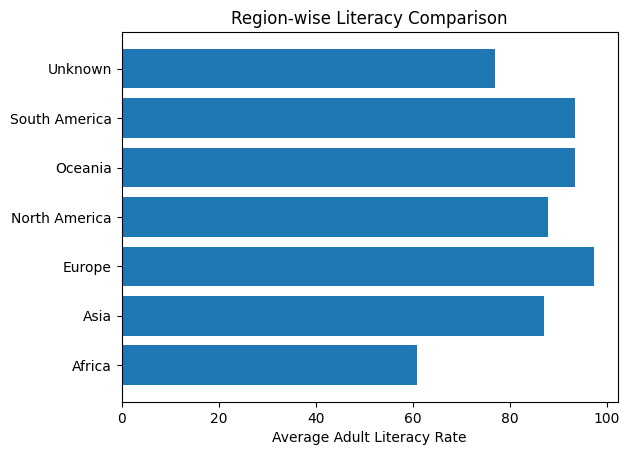

In [ ]:

df = pd.read_sql("SELECT owid_region,AVG(adult_literacy_rate) AS avg_adult_literacy FROM literacy_rates GROUP BY owid_region;", conn)

regions = df['owid_region']
values = df['avg_adult_literacy']

plt.barh(regions, values)
plt.xlabel("Average Adult Literacy Rate")
plt.title("Region-wise Literacy Comparison")
plt.show()

illiteracy_population

In [ ]:
df = pd.read_sql("SELECT Country, year, Illiteracy_Percentage FROM illiteracy_population WHERE year = 2000 AND Illiteracy_Percentage > 20;", conn)
df

,Country,year,Illiteracy_Percentage
0,Burundi,2000,41.00000
1,Cameroon,2000,32.00000
2,Central African Republic,2000,49.00000
3,Central and Southern Asia (SDG),2000,39.91697
4,Chad,2000,74.00000
...,...,...,...
135,South Asia (WB),2000,42.34942
136,Sub-Saharan Africa (SDG),2000,43.60940
137,Sub-Saharan Africa (WB),2000,43.37245
138,Sudan,2000,39.00000


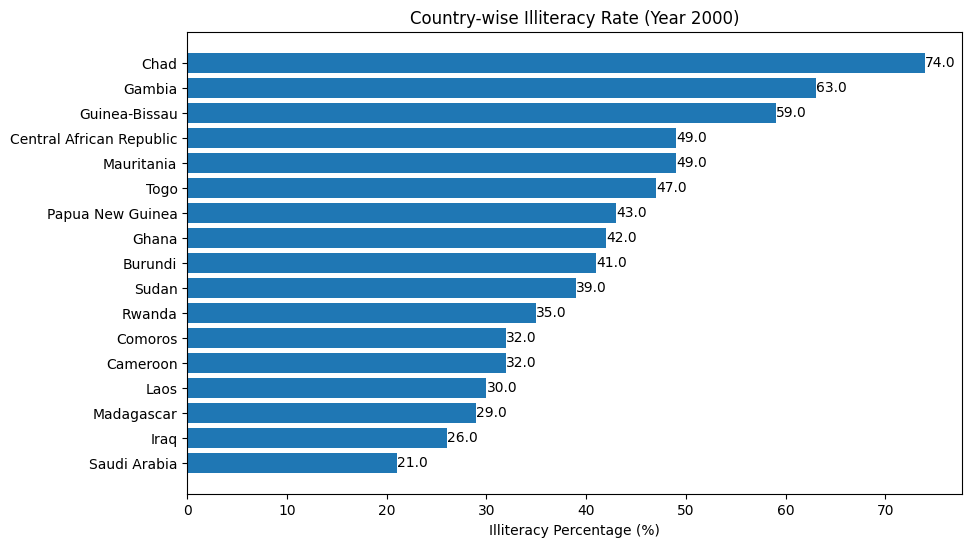

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Sample data (replace with your dataframe)
data = {
    "Country": ["Burundi","Cameroon","Central African Republic","Chad","Comoros",
                "Gambia","Ghana","Guinea-Bissau","Iraq","Laos","Madagascar",
                "Mauritania","Papua New Guinea","Rwanda","Saudi Arabia",
                "Sudan","Togo"],
    "Illiteracy_Percentage": [41,32,49,74,32,63,42,59,26,30,29,49,43,35,21,39,47]
}

df = pd.DataFrame(data)

# Sort for better visualization
df = df.sort_values(by="Illiteracy_Percentage")

plt.figure(figsize=(10,6))
plt.barh(df["Country"], df["Illiteracy_Percentage"])

# Add value labels
for i, v in enumerate(df["Illiteracy_Percentage"]):
    plt.text(v, i, f"{v:.1f}", va='center')

plt.xlabel("Illiteracy Percentage (%)")
plt.title("Country-wise Illiteracy Rate (Year 2000)")

plt.show()

In [ ]:
df = pd.read_sql("SELECT year, Illiteracy_Percentage FROM illiteracy_population WHERE Country = 'India' AND year BETWEEN 2000 AND 2020 ORDER BY year;", conn)
df

,year,Illiteracy_Percentage
0,2001,39.0
1,2001,39.0
2,2001,39.0
3,2001,39.0
4,2001,39.0
5,2006,37.0
6,2006,37.0
7,2006,37.0
8,2006,37.0
9,2006,37.0


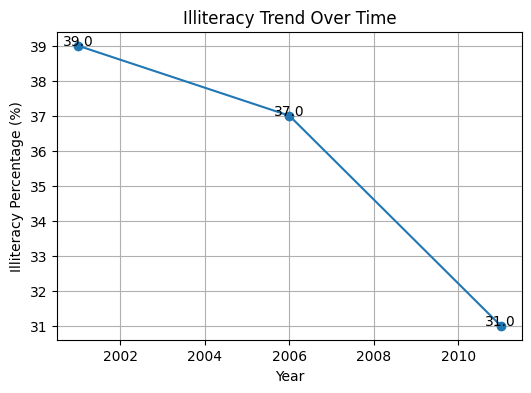

In [ ]:
import matplotlib.pyplot as plt
df = pd.read_sql("SELECT year, Illiteracy_Percentage FROM illiteracy_population WHERE Country = 'India' AND year BETWEEN 2000 AND 2020 ORDER BY year;", conn)
df
# Data
year = [2001, 2006, 2011]
illiteracy = [39.0, 37.0, 31.0]

plt.figure(figsize=(6,4))

plt.plot(year, illiteracy, marker='o')

# Labels
plt.xlabel("Year")
plt.ylabel("Illiteracy Percentage (%)")
plt.title("Illiteracy Trend Over Time")

# Value labels
for x, y in zip(year, illiteracy):
    plt.text(x, y, str(y), ha='center')

plt.grid(True)
plt.show()

In [ ]:
df = pd.read_sql("SELECT  i.Country, i.year, (i.Illiteracy_Percentage / 100.0 * g.population_historical) AS illiterate_population FROM illiteracy_population i JOIN gdp_schoolings g ON i.Country = g.Country AND i.year = g.year WHERE i.year = (SELECT MAX(year) FROM illiteracy_population) ORDER BY illiterate_population DESC LIMIT 10;", conn)
df

,Country,year,illiterate_population
0,Lower-middle-income countries,2023,6.896456e+08
1,Lower-middle-income countries,2023,6.896456e+08
2,Lower-middle-income countries,2023,6.896456e+08
3,Lower-middle-income countries,2023,6.896456e+08
4,Lower-middle-income countries,2023,6.896456e+08
5,Lower-middle-income countries,2023,6.896456e+08
6,Lower-middle-income countries,2023,6.896456e+08
7,Lower-middle-income countries,2023,6.896456e+08
8,Lower-middle-income countries,2023,6.896456e+08
9,Lower-middle-income countries,2023,6.896456e+08


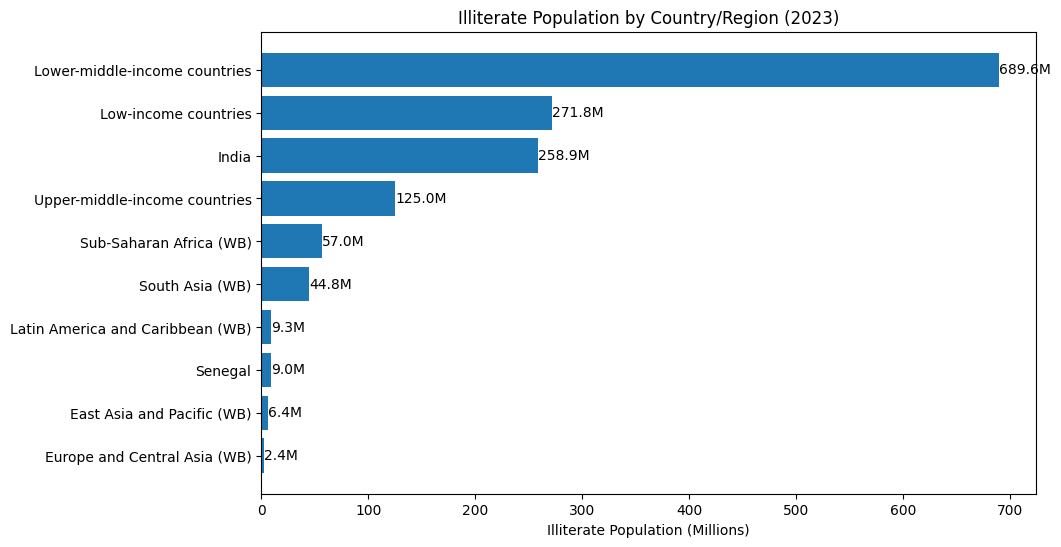

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_sql("SELECT  i.Country, i.year, (i.Illiteracy_Percentage / 100.0 * g.population_historical) AS illiterate_population FROM illiteracy_population i JOIN gdp_schoolings g ON i.Country = g.Country AND i.year = g.year WHERE i.year = (SELECT MAX(year) FROM illiteracy_population) ORDER BY illiterate_population DESC LIMIT 10;", conn)
# Your data
data = {
    "Country": ["Lower-middle-income countries","Low-income countries","India",
                "Upper-middle-income countries","Sub-Saharan Africa (WB)",
                "South Asia (WB)","Latin America and Caribbean (WB)",
                "Senegal","East Asia and Pacific (WB)",
                "Europe and Central Asia (WB)"],

    "illiterate_population": [6.896456e+08,2.718095e+08,2.588525e+08,
                             1.249694e+08,5.703764e+07,4.481974e+07,
                             9.343723e+06,8.974463e+06,6.401646e+06,2.351699e+06]
}

df = pd.DataFrame(data)

# Convert to millions for readability
df["illiterate_population_millions"] = df["illiterate_population"] / 1e6

# Sort
df = df.sort_values(by="illiterate_population_millions")

plt.figure(figsize=(10,6))
plt.barh(df["Country"], df["illiterate_population_millions"])

# Value labels
for i, v in enumerate(df["illiterate_population_millions"]):
    plt.text(v, i, f"{v:.1f}M", va='center')

plt.xlabel("Illiterate Population (Millions)")
plt.title("Illiterate Population by Country/Region (2023)")

plt.show()

Gdp_schooling

In [ ]:
df = pd.read_sql("SELECT Country, year, GDP_Per_Capita, Average_years_of_education_15_64 FROM gdp_schoolings WHERE Average_years_of_education_15_64 > 7 AND GDP_Per_Capita < 5000;", conn)
df

,Country,year,GDP_Per_Capita,Average_years_of_education_15_64
0,Afghanistan,2011,2757.0525,8.190541
1,Afghanistan,2021,2144.1665,8.190541
2,Bangladesh,1991,2101.3835,8.190541
3,Bangladesh,2001,2803.5547,8.190541
4,Bangladesh,2011,4352.4263,8.190541
...,...,...,...,...
1530,Zambia,2020,3391.5955,8.370000
1531,Zimbabwe,2005,4004.6646,7.650000
1532,Zimbabwe,2010,3885.3938,7.860000
1533,Zimbabwe,2019,4993.8438,8.190541


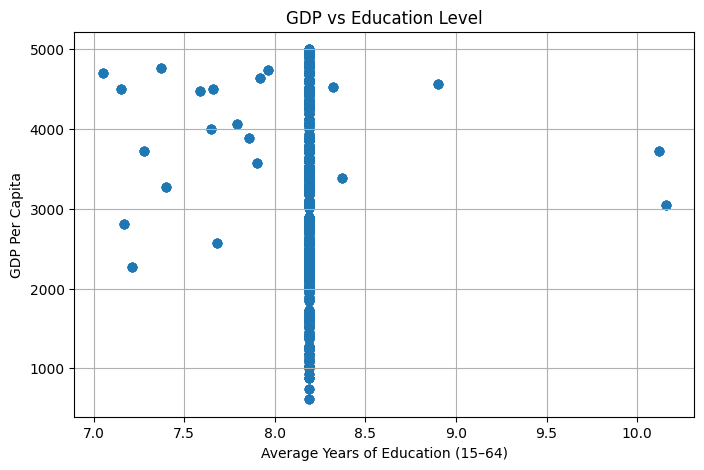

In [ ]:
df = pd.read_sql("SELECT Country, year, GDP_Per_Capita, Average_years_of_education_15_64 FROM gdp_schoolings WHERE Average_years_of_education_15_64 > 7 AND GDP_Per_Capita < 5000;", conn)
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(df["Average_years_of_education_15_64"],
            df["GDP_Per_Capita"])

plt.xlabel("Average Years of Education (15–64)")
plt.ylabel("GDP Per Capita")
plt.title("GDP vs Education Level")

plt.grid(True)
plt.show()

In [ ]:
df = pd.read_sql("SELECT Country, year, GDP_per_Schooling_Year, RANK() OVER (ORDER BY GDP_per_Schooling_Year DESC) AS rank FROM gdp_schoolings WHERE year = 2020;", conn)
df

,Country,year,GDP_per_Schooling_Year,rank
0,Qatar,2020,12096.467136,1
1,Qatar,2020,12096.467136,1
2,Qatar,2020,12096.467136,1
3,Qatar,2020,12096.467136,1
4,Qatar,2020,12096.467136,1
...,...,...,...,...
755,Burundi,2020,204.112931,756
756,Burundi,2020,204.112931,756
757,Burundi,2020,204.112931,756
758,Burundi,2020,204.112931,756


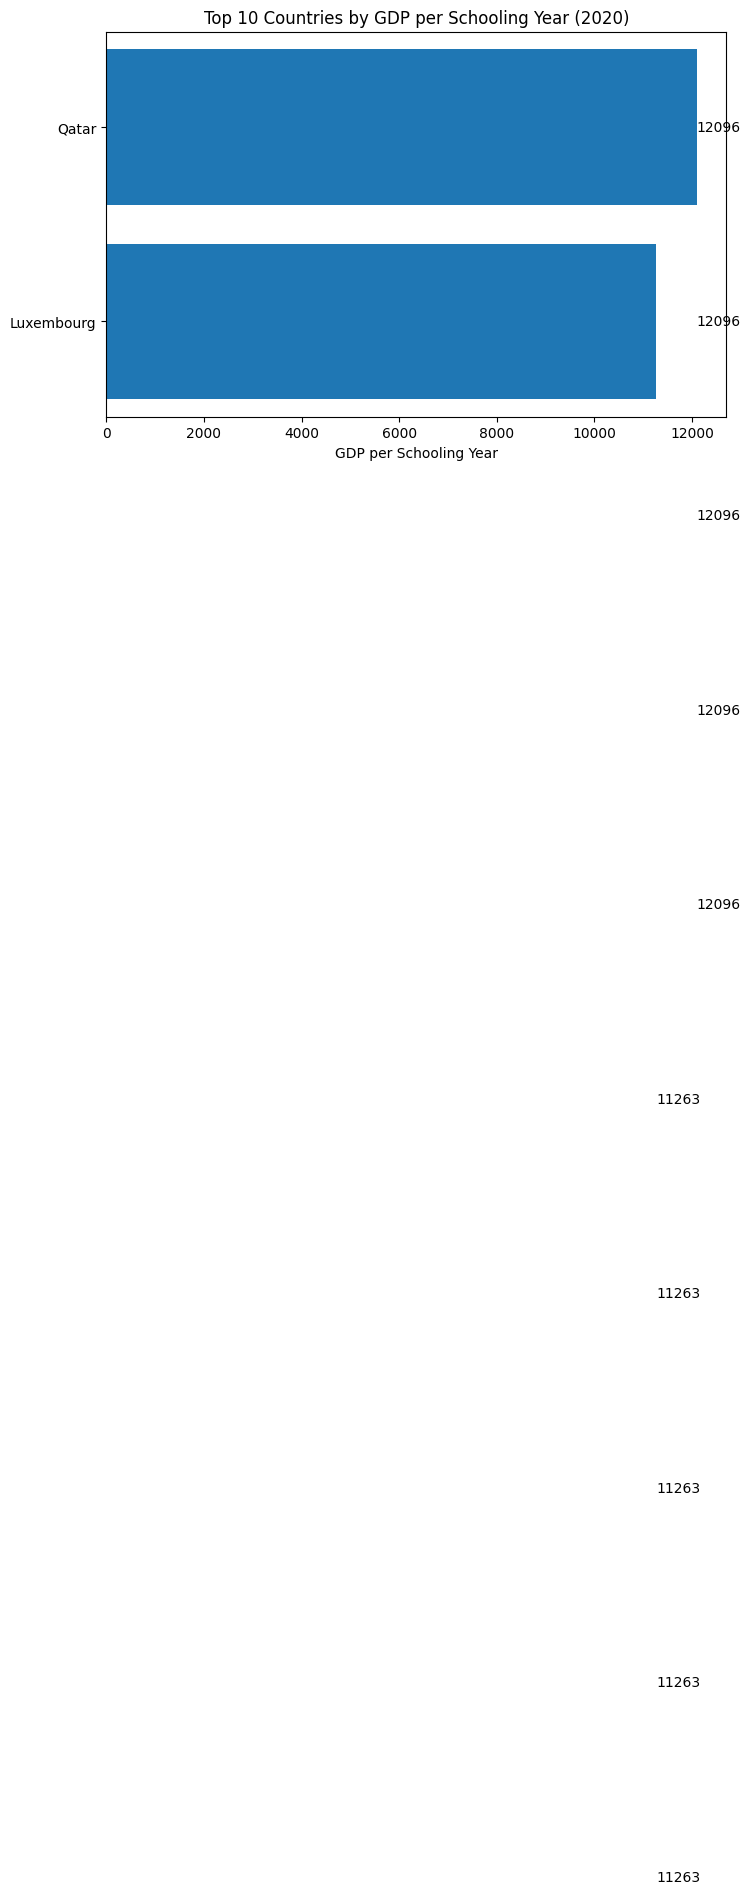

In [ ]:
df = pd.read_sql("SELECT Country, year, GDP_per_Schooling_Year, RANK() OVER (ORDER BY GDP_per_Schooling_Year DESC) AS rank FROM gdp_schoolings WHERE year = 2020;", conn)
import matplotlib.pyplot as plt

# Top 10 countries (already sorted by rank)
top10 = df.nsmallest(10, "rank")

plt.figure(figsize=(8,5))
plt.barh(top10["Country"], top10["GDP_per_Schooling_Year"])

plt.gca().invert_yaxis()  # Rank 1 at top

# Value labels
for i, v in enumerate(top10["GDP_per_Schooling_Year"]):
    plt.text(v, i, f"{v:.0f}", va='center')

plt.xlabel("GDP per Schooling Year")
plt.title("Top 10 Countries by GDP per Schooling Year (2020)")

plt.show()

In [ ]:
df = pd.read_sql("SELECT year, AVG(Average_years_of_education_15_64) AS avg_schooling_years FROM gdp_schoolings GROUP BY year ORDER BY year;", conn)
df

,year,avg_schooling_years
0,1990,6.864366
1,1991,8.190541
2,1992,8.190541
3,1993,8.190541
4,1994,8.190541
5,1995,7.326000
6,1996,8.190541
7,1997,8.190541
8,1998,8.190541
9,1999,8.190541


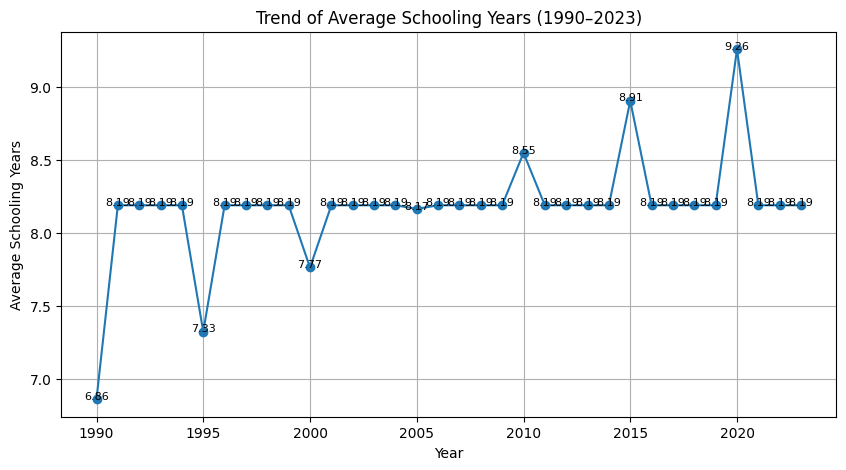

In [ ]:
df = pd.read_sql("SELECT year, AVG(Average_years_of_education_15_64) AS avg_schooling_years FROM gdp_schoolings GROUP BY year ORDER BY year;", conn)
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(df["year"], df["avg_schooling_years"], marker='o')

# Add value labels (optional for clarity)
for x, y in zip(df["year"], df["avg_schooling_years"]):
    plt.text(x, y, f"{y:.2f}", ha='center', fontsize=8)

plt.xlabel("Year")
plt.ylabel("Average Schooling Years")
plt.title("Trend of Average Schooling Years (1990–2023)")

plt.grid(True)
plt.show()

      Country  GDP_Per_Capita  Average_years_of_education_15_64
0    Cambodia       6128.7820                              5.81
1    Cambodia       6128.7820                              5.81
2    Cambodia       6128.7820                              5.81
3    Cambodia       6128.7820                              5.81
4    Cambodia       6128.7820                              5.81
5  Mauritania       5963.2354                              5.55
6  Mauritania       5963.2354                              5.55
7  Mauritania       5963.2354                              5.55
8  Mauritania       5963.2354                              5.55
9  Mauritania       5963.2354                              5.55


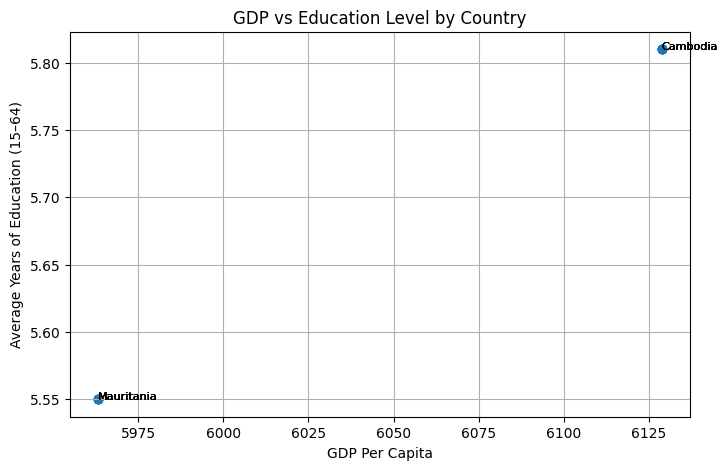

In [ ]:
df = pd.read_sql("SELECT Country, GDP_Per_Capita, Average_years_of_education_15_64 FROM gdp_schoolings WHERE year = 2020 AND Average_years_of_education_15_64 < 6 ORDER BY GDP_Per_Capita DESC LIMIT 10;",conn)
df
print(df)


import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(df["GDP_Per_Capita"], df["Average_years_of_education_15_64"])

# Add country labels
for i in range(len(df)):
    plt.text(df["GDP_Per_Capita"][i],
             df["Average_years_of_education_15_64"][i],
             df["Country"][i], fontsize=8)

plt.xlabel("GDP Per Capita")
plt.ylabel("Average Years of Education (15–64)")
plt.title("GDP vs Education Level by Country")

plt.grid(True)
plt.show()

In [ ]:
df = pd.read_sql("SELECT  Country, year, Average_years_of_education_15_64, Illiteracy_rate, population_historical, (Illiteracy_rate / 100.0 * population_historical) AS illiterate_population FROM gdp_schoolings WHERE Average_years_of_education_15_64 > 10 AND (Illiteracy_rate / 100.0 * population_historical) > 1000000 ORDER BY illiterate_population DESC;", conn)
df

,Country,year,Average_years_of_education_15_64,Illiteracy_rate,population_historical,illiterate_population
0,United States,2020,13.32,20.070693,339436156.0,6.812719e+07
1,United States,2020,13.32,20.070693,339436156.0,6.812719e+07
2,United States,2020,13.32,20.070693,339436156.0,6.812719e+07
3,United States,2020,13.32,20.070693,339436156.0,6.812719e+07
4,United States,2020,13.32,20.070693,339436156.0,6.812719e+07
...,...,...,...,...,...,...
880,Ireland,2020,13.74,20.070693,4982602.0,1.000043e+06
881,Ireland,2020,13.74,20.070693,4982602.0,1.000043e+06
882,Ireland,2020,13.74,20.070693,4982602.0,1.000043e+06
883,Ireland,2020,13.74,20.070693,4982602.0,1.000043e+06


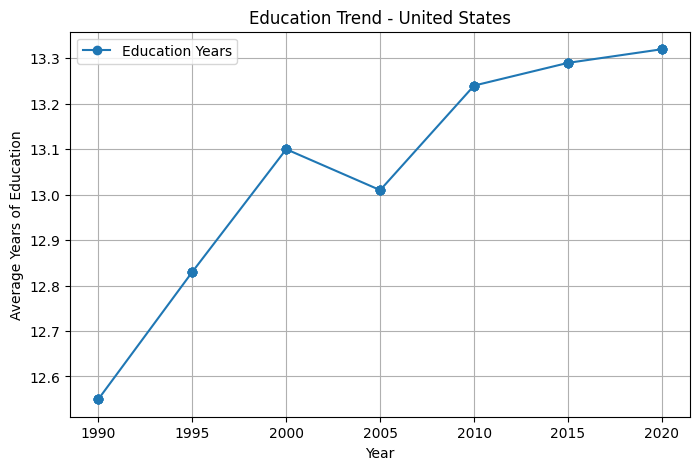

In [ ]:
df = pd.read_sql("SELECT  Country, year, Average_years_of_education_15_64, Illiteracy_rate, population_historical, (Illiteracy_rate / 100.0 * population_historical) AS illiterate_population FROM gdp_schoolings WHERE Average_years_of_education_15_64 > 10 AND (Illiteracy_rate / 100.0 * population_historical) > 1000000 ORDER BY illiterate_population DESC;", conn)

import matplotlib.pyplot as plt

# Example: filter one country (important!)
df_country = df[df["Country"] == "United States"]

plt.figure(figsize=(8,5))

plt.plot(df_country["year"],
         df_country["Average_years_of_education_15_64"],
         marker='o', label="Education Years")

plt.xlabel("Year")
plt.ylabel("Average Years of Education")
plt.title("Education Trend - United States")

plt.legend()
plt.grid(True)
plt.show()



    year  literacy_rate  GDP_Per_Capita  GDP_Growth_Rate
0   2005      79.929307       59604.754              NaN
1   2005      79.929307       59604.754         0.000000
2   2005      79.929307       59604.754         0.000000
3   2005      79.929307       59604.754         0.000000
4   2005      79.929307       59604.754         0.000000
5   2010      79.929307       59789.414         0.309808
6   2010      79.929307       59789.414         0.000000
7   2010      79.929307       59789.414         0.000000
8   2010      79.929307       59789.414         0.000000
9   2010      79.929307       59789.414         0.000000
10  2015      79.929307       64359.473         7.643592
11  2015      79.929307       64359.473         0.000000
12  2015      79.929307       64359.473         0.000000
13  2015      79.929307       64359.473         0.000000
14  2015      79.929307       64359.473         0.000000
15  2020      79.929307       67342.070         4.634278
16  2020      79.929307       6

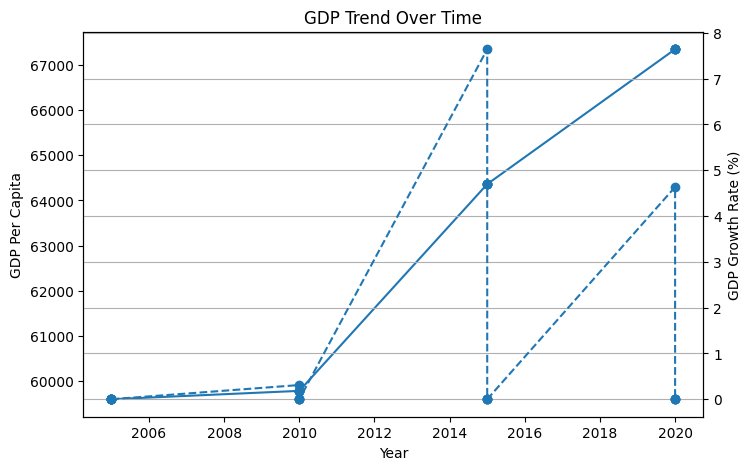

In [ ]:
df = pd.read_sql("SELECT year, literacy_rate, GDP_Per_Capita,((GDP_Per_Capita - LAG(GDP_Per_Capita) OVER (ORDER BY year))  / LAG(GDP_Per_Capita) OVER (ORDER BY year)) * 100 AS GDP_Growth_Rate FROM gdp_schoolings WHERE Country = 'United States' AND year >= (SELECT MAX(year) - 20 FROM gdp_schoolings) ORDER BY year;", conn)
print(df)

import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(8,5))

# Primary axis (GDP Per Capita)
ax1.plot(df["year"], df["GDP_Per_Capita"], marker='o', label="GDP Per Capita")
ax1.set_xlabel("Year")
ax1.set_ylabel("GDP Per Capita")

# Secondary axis (GDP Growth Rate)
ax2 = ax1.twinx()
ax2.plot(df["year"], df["GDP_Growth_Rate"], marker='o', linestyle='--', label="GDP Growth Rate")
ax2.set_ylabel("GDP Growth Rate (%)")

plt.title("GDP Trend Over Time")

plt.grid(True)
plt.show()


In [ ]:
df = pd.read_sql("SELECT l.Country,l.year,l.Youth_literacy_rate_male,l.Youth_literacy_rate_female, (l.Youth_literacy_rate_male - l.Youth_literacy_rate_female) AS literacy_difference,g.GDP_Per_Capita FROM literacy_rates l JOIN gdp_schoolings g ON l.Country = g.Country  AND l.year = g.year WHERE l.year = 2020 AND g.GDP_Per_Capita > 30000 ORDER BY literacy_difference DESC;", conn)
df

,Country,year,Youth_literacy_rate_male,Youth_literacy_rate_female,literacy_difference,GDP_Per_Capita
0,Saudi Arabia,2020,100.0,99.0,1.0,57420.734
1,Saudi Arabia,2020,100.0,99.0,1.0,57420.734
2,Saudi Arabia,2020,100.0,99.0,1.0,57420.734
3,Saudi Arabia,2020,100.0,99.0,1.0,57420.734
4,Saudi Arabia,2020,100.0,99.0,1.0,57420.734
...,...,...,...,...,...,...
170,Spain,2020,99.0,100.0,-1.0,41553.450
171,Spain,2020,99.0,100.0,-1.0,41553.450
172,Spain,2020,99.0,100.0,-1.0,41553.450
173,Spain,2020,99.0,100.0,-1.0,41553.450


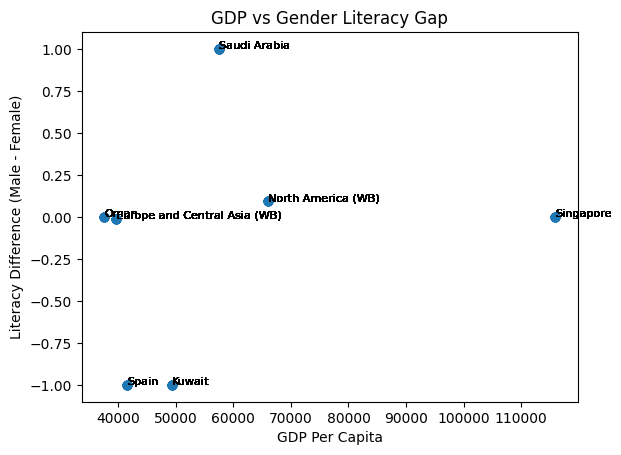

In [ ]:
df = pd.read_sql("SELECT l.Country,l.year,l.Youth_literacy_rate_male,l.Youth_literacy_rate_female, (l.Youth_literacy_rate_male - l.Youth_literacy_rate_female) AS literacy_difference,g.GDP_Per_Capita FROM literacy_rates l JOIN gdp_schoolings g ON l.Country = g.Country  AND l.year = g.year WHERE l.year = 2020 AND g.GDP_Per_Capita > 30000 ORDER BY literacy_difference DESC;", conn)
plt.scatter(df["GDP_Per_Capita"], df["literacy_difference"])

for i in range(len(df)):
    plt.text(df["GDP_Per_Capita"][i], df["literacy_difference"][i], df["Country"][i], fontsize=8)

plt.xlabel("GDP Per Capita")
plt.ylabel("Literacy Difference (Male - Female)")
plt.title("GDP vs Gender Literacy Gap")
plt.show()


In [ ]:
!pip install -q streamlit
!wget https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared-linux-amd64
import subprocess
subprocess.Popen(["./cloudflared-linux-amd64", "tunnel", "--url", "http://localhost:8501"])
!nohup /content/cloudflared-linux-amd64 tunnel --url http://localhost:8501 &

--2026-04-16 18:23:20--  https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/cloudflare/cloudflared/releases/download/2026.3.0/cloudflared-linux-amd64 [following]
--2026-04-16 18:23:21--  https://github.com/cloudflare/cloudflared/releases/download/2026.3.0/cloudflared-linux-amd64
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/106867604/731ab2f8-6b77-4adb-a7b3-1104525e9d72?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-04-16T19%3A02%3A32Z&rscd=attachment%3B+filename%3Dcloudflared-linux-amd64&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-04-16T1

In [ ]:
!pip install streamlit-option-menu

In [ ]:
%%writefile appm.py
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from streamlit_option_menu import option_menu
import sqlite3
#from pandas._config.config import options

# -----------------------------
# DB Connection
# -----------------------------
conn = sqlite3.connect("GLE.db")
cursor = conn.cursor()

# -----------------------------
# Load Data
# -----------------------------
df_lit = pd.read_csv("df_literacy.csv")
df_ill = pd.read_csv("illiterate_world_population.csv")
df_gdp = pd.read_csv("gdp_schooling.csv")

st.title("Global Literacy & Education Trends")
# -----------------------------
# Sidebar Menu
# -----------------------------
with st.sidebar:
    selected = option_menu(
        "Dashboard Menu",
        ("SQL Query Executor","EDA Visualizations", "Country Profile Page")
    )

if selected == "SQL Query Executor":
    st.title("SQL Query Executor")
    option = st.selectbox(
        "Dashboard Menu",
        ("I. Literacy_rates",
         "1. Get top 5 countries with highest adult literacy in 2020.",
         "2. Find countries where female youth literacy < 80%.",
         "3. Average adult literacy per continent (owid region).",
         "4. Countries with illiteracy % > 20% in 2000.",
         "5. Trend of illiteracy % for India (2000–2020).",
         "6. Top 10 countries with largest illiterate population in the last year.",
         "7. Find countries with avg_years_schooling > 7 and gdp_per_capita < 5000.",
         "8. Rank countries by GDP per schooling for the year 2020.",
         "9. Find global average schooling years per year.",
         "10. List top 10 countries in 2020 with highest GDP per capita but lowest averageyears of schooling(less than 6).",
         "11. Show countries where the illiterate population is high despite having more than 10 average years of schooling.",
         "12. Compare literacy rates and GDP per capita growth for a selected country over the last 20 years. (country of your choice)",
         "13. Show the difference between youth literacy male and female rates for countries with GDP per capita above $30,000 in 2020."),
)
    if option == "I. Literacy_rates":
        filtered_df = pd.read_sql("SELECT * FROM literacy_rates", con = conn)
        st.dataframe(filtered_df)

    elif option == "1. Get top 5 countries with highest adult literacy in 2020.":
          filtered_df = pd.read_sql("SELECT Country, adult_literacy_rate FROM literacy_rates WHERE year = 2020 ORDER BY adult_literacy_rate DESC LIMIT 5", con = conn)
          st.dataframe(filtered_df)
          # Create figure
          fig, ax = plt.subplots()

          ax.barh(filtered_df['Country'], filtered_df['adult_literacy_rate'])
          ax.set_xlabel("Adult Literacy Rate")
          ax.set_title("Top 5 Countries by Adult Literacy Rate (2020)")
          # Display in Streamlit
          st.pyplot(fig)

    elif option == "2. Find countries where female youth literacy < 80%.":
          # Title
          st.title("Literacy Trend Analysis")
          # Load data from SQL
          df = pd.read_sql("SELECT Country,year,adult_literacy_rate,Youth_literacy_rate_male,Youth_literacy_rate_female,owid_region,literacy_gender_gap,Youth_Literacy_Average FROM literacy_rates WHERE Youth_literacy_rate_female < 80;", conn)
          country = st.selectbox("Select Country", df["Country"].unique())

          # Filter data
          df_country = df[df["Country"] == country]

          # Show data
          st.dataframe(df_country)

          # Plot
          st.subheader(f"Literacy Trend - {country}")

          fig, ax = plt.subplots()

          ax.plot(df_country["year"], df_country["adult_literacy_rate"], label="Adult")
          ax.plot(df_country["year"], df_country["Youth_literacy_rate_male"], label="Male Youth")
          ax.plot(df_country["year"], df_country["Youth_literacy_rate_female"], label="Female Youth")

          ax.set_xlabel("Year")
          ax.set_ylabel("Literacy Rate")
          ax.set_title(f"Literacy Trend - {country}")
          ax.legend()

          # Show in Streamlit
          st.pyplot(fig)
    elif option == "3. Average adult literacy per continent (owid region).":
          # Title
          st.title("Region-wise Literacy Comparison")

          df = pd.read_sql("SELECT owid_region,AVG(adult_literacy_rate) AS avg_adult_literacy FROM literacy_rates GROUP BY owid_region;", conn)

          # Show data
          st.dataframe(df)

          # Sort values for better visualization
          df = df.sort_values(by="avg_adult_literacy", ascending=True)

          # Plot
          st.subheader("Average Adult Literacy Rate by Region")

          fig, ax = plt.subplots()

          ax.barh(df["owid_region"], df["avg_adult_literacy"])

          ax.set_xlabel("Average Adult Literacy Rate")
          ax.set_ylabel("Region")
          ax.set_title("Region-wise Literacy Comparison")

          # Show in Streamlit
          st.pyplot(fig)

    elif option == "4. Countries with illiteracy % > 20% in 2000.":
          df = pd.read_sql("SELECT Country, year, Illiteracy_Percentage FROM illiteracy_population WHERE year = 2000 AND Illiteracy_Percentage > 20;", conn)
          st.title("Country-wise Illiteracy Rate (Year 2000)")
          df = df.sort_values(by="Illiteracy_Percentage")
          st.dataframe(df)
          # Plot
          st.subheader("Illiteracy Percentage by Country")
          fig, ax = plt.subplots(figsize=(10,6))
          ax.barh(df["Country"], df["Illiteracy_Percentage"])
          for i, v in enumerate(df["Illiteracy_Percentage"]):
              ax.text(v, i, f"{v:.1f}", va='center')

          ax.set_xlabel("Illiteracy Percentage (%)")
          ax.set_ylabel("Country")
          ax.set_title("Country-wise Illiteracy Rate (2000)")

          # Show chart
          st.pyplot(fig)

    elif option == "5. Trend of illiteracy % for India (2000-2020).":
          st.title("Illiteracy Trend Over Time")
          df = pd.read_sql("SELECT year, Illiteracy_Percentage FROM illiteracy_population WHERE Country = 'India' AND year BETWEEN 2000 AND 2020 ORDER BY year;", conn)
          st.dataframe(df)
          # Country selection (dynamic instead of hardcoding India)
          country = st.selectbox("Select Country", ["India"])  # you can later replace with dynamic list
          df = df[df["Country"] == country]

          st.subheader(f"Illiteracy Trend - {country}")
          fig, ax = plt.subplots(figsize=(6,4))
          ax.plot(df["year"], df["Illiteracy_Percentage"], marker='o')

          # Labels
          ax.set_xlabel("Year")
          ax.set_ylabel("Illiteracy Percentage (%)")
          ax.set_title("Illiteracy Trend Over Time")

          # Value labels
          for x, y in zip(df["year"], df["Illiteracy_Percentage"]):
              ax.text(x, y, f"{y}", ha='center')

          ax.grid(True)
          st.pyplot(fig)

    elif option == "6. Top 10 countries with largest illiterate population in the last year.":
          df = pd.read_sql("SELECT  i.Country, i.year, (i.Illiteracy_Percentage / 100.0 * g.population_historical) AS illiterate_population FROM illiteracy_population i JOIN gdp_schoolings g ON i.Country = g.Country AND i.year = g.year WHERE i.year = (SELECT MAX(year) FROM illiteracy_population) ORDER BY illiterate_population DESC LIMIT 10;", conn)
          st.title("Top 10 Illiterate Population by Country/Region")
          df["illiterate_population_millions"] = df["illiterate_population"] / 1e6
          df = df.sort_values(by="illiterate_population_millions")
          st.dataframe(df)

          st.subheader("Illiterate Population (in Millions)")
          fig, ax = plt.subplots(figsize=(10,6))
          ax.barh(df["Country"], df["illiterate_population_millions"])

          # Value labels
          for i, v in enumerate(df["illiterate_population_millions"]):
              ax.text(v, i, f"{v:.1f}M", va='center')

          ax.set_xlabel("Illiterate Population (Millions)")
          ax.set_ylabel("Country / Region")
          ax.set_title("Top 10 Illiterate Population")
          st.pyplot(fig)

    elif option == "7. Find countries with avg_years_schooling > 7 and gdp_per_capita < 5000.":
          st.title("GDP vs Education Level")
          df = pd.read_sql("SELECT Country, year, GDP_Per_Capita, Average_years_of_education_15_64 FROM gdp_schoolings WHERE Average_years_of_education_15_64 > 7 AND GDP_Per_Capita < 5000;", conn)
          st.dataframe(df)
          st.subheader("Scatter Plot: GDP vs Education")
          fig, ax = plt.subplots(figsize=(8,5))

          ax.scatter(
              df["Average_years_of_education_15_64"],
              df["GDP_Per_Capita"]
          )
          ax.set_xlabel("Average Years of Education (15–64)")
          ax.set_ylabel("GDP Per Capita")
          ax.set_title("GDP vs Education Level")
          ax.grid(True)
          st.pyplot(fig)

    elif option == "8. Rank countries by GDP per schooling for the year 2020.":
          df = pd.read_sql("SELECT Country, year, GDP_per_Schooling_Year, RANK() OVER (ORDER BY GDP_per_Schooling_Year DESC) AS rank FROM gdp_schoolings WHERE year = 2020;", conn)
          st.title("Top 10 Countries by GDP per Schooling Year (2020)")
          top10 = df.nsmallest(10, "rank")
          # Sort for better horizontal display (Rank 1 on top)
          top10 = top10.sort_values(by="rank", ascending=False)
          st.dataframe(top10)
          st.subheader("Top 10 Countries")
          fig, ax = plt.subplots(figsize=(8,5))
          ax.bar(top10["Country"], top10["GDP_per_Schooling_Year"])

          # Value labels
          for i, v in enumerate(top10["GDP_per_Schooling_Year"]):
              ax.text(v, i, f"{v:.0f}", va='center')

          ax.set_xlabel("GDP per Schooling Year")
          ax.set_ylabel("Country")
          ax.set_title("Top 10 Countries by GDP per Schooling Year (2020)")
          st.pyplot(fig)



    elif option == "":
          df = pd.read_sql("SELECT year, AVG(Average_years_of_education_15_64) AS avg_schooling_years FROM gdp_schoolings GROUP BY year ORDER BY year;", conn)

          st.title("Trend of Average Schooling Years")
          st.dataframe(df)
          st.subheader("Average Schooling Years Over Time")
          fig, ax = plt.subplots(figsize=(10,5))
          ax.plot(df["year"], df["avg_schooling_years"], marker='o')

          # Value labels
          for x, y in zip(df["year"], df["avg_schooling_years"]):
              ax.text(x, y, f"{y:.2f}", ha='center', fontsize=8)

          ax.set_xlabel("Year")
          ax.set_ylabel("Average Schooling Years")
          ax.set_title("Trend of Average Schooling Years (1990–2023)")
          ax.grid(True)
          st.pyplot(fig)

    elif option == "13. Show the difference between youth literacy male and female rates for countries with GDP per capita above $30,000 in 2020.":
          df = pd.read_sql("SELECT l.Country,l.year,l.Youth_literacy_rate_male,l.Youth_literacy_rate_female, (l.Youth_literacy_rate_male - l.Youth_literacy_rate_female) AS literacy_difference,g.GDP_Per_Capita FROM literacy_rates l JOIN gdp_schoolings g ON l.Country = g.Country  AND l.year = g.year WHERE l.year = 2020 AND g.GDP_Per_Capita > 30000 ORDER BY literacy_difference DESC;", conn)
          st.dataframe(df)
          fig, ax = plt.subplots()
          ax.scatter(df["GDP_Per_Capita"], df["literacy_difference"])

          for i in range(len(df)):
              ax.text(df["GDP_Per_Capita"][i], df["literacy_difference"][i], df["Country"][i], fontsize=8)

          ax.set_xlabel("GDP Per Capita")
          ax.set_ylabel("Literacy Difference (Male - Female)")
          ax.set_title("GDP vs Gender Literacy Gap")
          st.pyplot(fig)



if selected == "EDA Visualizations":
    st.title("EDA Visualizations")
    option = st.selectbox(
        "📊 Dashboard Menu",
        ("Gender Gap", "GDP vs Literacy", "Schooling vs Literacy", "Top/Bottom", "Global Dashboard", "Illiteracy vs Population Impact","Regional Analysis","Illiteracy vs Population","Literacy Projection","Crisis Impact"),
    )

    # =========================================================
    # 1. GENDER GAP DASHBOARD
    # =========================================================
    if option == "Gender Gap":

        st.title("🌍 Gender Disparities in Youth Literacy")

        df_lit['Gender_Gap'] = df_lit['Youth_literacy_rate_male'] - df_lit['Youth_literacy_rate_female']

        country = st.selectbox("Select Country", df_lit['Country'].unique())
        region = st.selectbox("Select Region", df_lit['owid_region'].unique())

        filtered = df_lit[(df_lit['Country'] == country) & (df_lit['owid_region'] == region)]

        col1, col2, col3 = st.columns(3)
        col1.metric("Male", round(filtered['Youth_literacy_rate_male'].mean(), 2))
        col2.metric("Female", round(filtered['Youth_literacy_rate_female'].mean(), 2))
        col3.metric("Gap", round(filtered['Gender_Gap'].mean(), 2))

        fig, ax = plt.subplots()
        ax.plot(filtered['year'], filtered['Youth_literacy_rate_male'], label='Male')
        ax.plot(filtered['year'], filtered['Youth_literacy_rate_female'], label='Female')
        ax.legend()
        st.pyplot(fig)

  # =========================================================
  # 2. GDP vs LITERACY
  # =========================================================
    elif option == "GDP vs Literacy":
        st.title("💰 Literacy vs GDP")

        region = st.selectbox("Region", df_gdp['owid_region'].dropna().unique())
        year = st.selectbox("Year", sorted(df_gdp['year'].dropna().unique()))

        filtered = df_gdp[(df_gdp['owid_region'] == region) & (df_gdp['year'] == year)]

        fig, ax = plt.subplots()
        ax.scatter(filtered['GDP_Per_Capita'], filtered['literacy_rate'])
        st.pyplot(fig)

        corr = filtered['GDP_Per_Capita'].corr(filtered['literacy_rate'])
        st.write("Correlation:", round(corr, 2))

    # =========================================================
    # 3. SCHOOLING vs LITERACY
    # =========================================================
    elif option == "Schooling vs Literacy":
        st.title("🎓 Schooling vs Literacy")

        year = st.selectbox("Year", sorted(df_gdp['year'].dropna().unique()))
        filtered = df_gdp[df_gdp['year'] == year]

        x = filtered['Average_years_of_education_15_64']
        y = filtered['literacy_rate']

        fig, ax = plt.subplots()
        ax.scatter(x, y)

        m, b = np.polyfit(x.fillna(0), y.fillna(0), 1)
        ax.plot(x, m*x + b)

        st.pyplot(fig)

    # =========================================================
    # 4. TOP & BOTTOM COUNTRIES
    # =========================================================
    elif option == "Top/Bottom":
        st.title("Top & Bottom Literacy")

        year = st.selectbox("Year", sorted(df_lit['year'].unique()))

        lit = df_lit[df_lit['year'] == year]
        ill = df_ill[df_ill['year'] == year]

        df = lit.merge(ill[['Country','year','illiteracy_rate']],
                      on=['Country','year'], how='left')

        top10 = df.sort_values('adult_literacy_rate', ascending=False).head(10)
        bottom10 = df.sort_values('illiteracy_rate', ascending=False).head(10)

        st.bar_chart(top10.set_index('Country')['adult_literacy_rate'])
        st.bar_chart(bottom10.set_index('Country')['illiteracy_rate'])

    # =========================================================
    # 5. GLOBAL DASHBOARD
    # =========================================================
    elif option == "Global Dashboard":
        st.title("🌍 Global Literacy Dashboard")

        year = st.selectbox("Year", sorted(df_lit['year'].unique()))
        country = st.selectbox("Country", df_lit['Country'].unique())

        lit = df_lit[df_lit['year'] == year]
        ill = df_ill[df_ill['year'] == year]
        gdp = df_gdp[df_gdp['year'] == year]

        df = lit.merge(ill[['Country','year','illiteracy_rate']], on=['Country','year'], how='left')
        df = df.merge(gdp[['Country','year','GDP_Per_Capita']], on=['Country','year'], how='left')

        fig, ax = plt.subplots()
        ax.scatter(df['GDP_Per_Capita'], df['adult_literacy_rate'])
        st.pyplot(fig)


    elif option == "Illiteracy vs Population Impact":
        st.title("Illiteracy vs Population Impact")

        df = df_ill.merge(
            df_gdp[['Country','year','population_historical']],
            on=['Country','year'],
            how='left'
        )

        df['Illiterate_Population'] = (df['illiteracy_rate'] / 100) * df['population_historical']

        year = st.selectbox("Select Year", sorted(df['year'].unique()))
        filtered = df[df['year'] == year]

        fig, ax = plt.subplots()
        ax.scatter(filtered['population_historical'], filtered['Illiterate_Population'])

        ax.set_xlabel("Total Population")
        ax.set_ylabel("Illiterate Population")

        st.pyplot(fig)

    # =========================================================
    # 7. REGIONAL ANALYSIS
    # =========================================================
    if option == "Regional Analysis":
        st.title("🌎 Regional Literacy Patterns")
        region_data = df_lit.groupby('owid_region')[['adult_literacy_rate','Youth_Literacy_Average']].mean()
        st.bar_chart(region_data)

    # =========================================================
    # 8. ILLITERACY vs POPULATION
    # =========================================================
    elif option == "Illiteracy vs Population":
        st.title("👥 Illiteracy vs Population")

        df_pop = df_ill.merge(df_gdp[['Country','year','population_historical']], on=['Country','year'], how='left')
        df_pop['Illiterate_Population'] = (df_pop['illiteracy_rate']/100) * df_pop['population_historical']

        year = st.selectbox("Year", sorted(df_pop['year'].unique()))
        filtered = df_pop[df_pop['year'] == year]

        fig, ax = plt.subplots()
        ax.scatter(filtered['population_historical'], filtered['Illiterate_Population'])

        st.pyplot(fig)

    # =========================================================
    # 9. PROJECTION
    # =========================================================
    elif option == "Literacy Projection":
        st.title("📈 Literacy Projection")

        country = st.selectbox("Country", df_lit['Country'].unique())
        cdf = df_lit[df_lit['Country'] == country].dropna()

        if len(cdf) > 1:
            x = cdf['year']
            y = cdf['adult_literacy_rate']

            m, b = np.polyfit(x, y, 1)
            future_years = np.arange(x.max(), x.max()+10)
            future = m * future_years + b

            fig, ax = plt.subplots()
            ax.plot(x, y, marker='o')
            ax.plot(future_years, future, linestyle='--')

            st.pyplot(fig)
        else:
            st.warning("Not enough data")

    # =========================================================
    # 10. CRISIS IMPACT
    # =========================================================
    elif option == "Crisis Impact":
        st.title("⚠️ Crisis Impact Analysis")

        country = st.selectbox("Country", df_lit['Country'].unique())
        cdf = df_lit[df_lit['Country'] == country].sort_values('year')

        if len(cdf) > 1:
            cdf['growth'] = cdf['adult_literacy_rate'].diff()
            slowdown = cdf[cdf['growth'] < 0]

            fig, ax = plt.subplots()
            ax.plot(cdf['year'], cdf['adult_literacy_rate'])
            ax.scatter(slowdown['year'], slowdown['adult_literacy_rate'])

            st.pyplot(fig)
        else:
            st.warning("Not enough data")

if selected == "Country Profile Page":
      st.title("Country Profile Page")
      country = st.selectbox("Select Country", df_lit["Country"].unique())

      df_lit = df_lit[df_lit["Country"] == country]
      df_ill = df_ill[df_ill["Country"] == country]
      df_gdp = df_gdp[df_gdp["Country"] == country]

      latest_lit = df_lit.sort_values("year").iloc[-1]
      latest_ill = df_ill.sort_values("year").iloc[-1]
      latest_gdp = df_gdp.sort_values("year").iloc[-1]
      col1, col2, col3, col4 = st.columns(4)

      col1.metric("Adult Literacy", f"{latest_lit['adult_literacy_rate']}%")
      col2.metric("Youth Literacy Avg", f"{latest_lit['Youth_Literacy_Average']}%")
      col3.metric("GDP per Capita", f"${latest_gdp['GDP_Per_Capita']}")
      col4.metric("Education Index", f"{latest_gdp['Education_Index']}")

      st.subheader("Literacy Trend")

      plt.figure()
      plt.plot(df_lit["year"], df_lit["adult_literacy_rate"], label="Adult Literacy")
      plt.plot(df_ill["year"], df_ill["literacy_rate"], label="Overall Literacy")
      plt.legend()
      st.pyplot(plt)

      st.subheader("Youth Literacy Gender Gap")

      plt.figure()
      plt.plot(df_lit["year"], df_lit["Youth_literacy_rate_male"], label="Male")
      plt.plot(df_lit["year"], df_lit["Youth_literacy_rate_female"], label="Female")
      plt.legend()
      st.pyplot(plt)

      st.write("Gender Gap:", latest_lit["literacy_gender_gap"])


      st.subheader("Illiteracy Trend")

      plt.figure()
      plt.plot(df_ill["year"], df_ill["illiteracy_rate"], label="Illiteracy Rate")
      plt.legend()
      st.pyplot(plt)

      st.subheader("GDP vs Education")

      plt.figure()
      plt.scatter(df_gdp["GDP_Per_Capita"], df_gdp["Education_Index"])
      plt.xlabel("GDP per Capita")
      plt.ylabel("Education Index")
      st.pyplot(plt)

      st.subheader("Schooling & Literacy")

      plt.figure()
      plt.plot(df_gdp["year"], df_gdp["Average_years_of_education_15_64"], label="Schooling Years")
      plt.legend()
      st.pyplot(plt)

      st.subheader("Composite Indicators")

      st.write("Literacy Index:", latest_gdp["Literacy_Index"])
      st.write("Schooling Index:", latest_gdp["Schooling_Index"])
      st.write("Education Index:", latest_gdp["Education_Index"])

      if latest_ill["illiteracy_rate"] < 10:
          st.success("Low illiteracy rate – strong education system")
      else:
          st.warning("High illiteracy rate – needs improvement")

      if latest_lit["literacy_gender_gap"] > 5:
          st.warning("Significant gender gap in literacy")
      else:
          st.success("Gender gap is minimal")


Overwriting appm.py


In [ ]:
!streamlit run /content/appm.py &>/content/logs.txt &

In [ ]:
!grep -o 'https://.*\.trycloudflare.com' nohup.out | head -n 1 | xargs -I {} echo "Your tunnel url {}"

Your tunnel url https://spies-time-toddler-climate.trycloudflare.com
